In [1]:
cd ../../..

/home/kozakmv/Programming/Python/boxmot


In [9]:
from pathlib import Path

import numpy as np
import cv2
from matplotlib import pyplot as plt

from boxmot.trackers.puretracker.display import visualize_tracking, plot_frame
from boxmot.trackers.puretracker.utils import xywh2xyxy_clip, xyxy2xywh, xywh2xyxy

from scipy.spatial.distance import cdist

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def load_dets(dets_path):
    dets: dict[str, list] = {}
    with open(dets_path, "r") as f:
        for line in f.readlines()[1:]:
            frame_id, x, y, w, h, conf, _ = map(float, line.strip().split())
            frame_id = int(frame_id)
            if frame_id not in dets:
                dets[frame_id] = []
            dets[frame_id].append((x, y, w, h, conf))
    return dets

In [6]:
# tracks_dirpath = Path("/home/kozakmv/Programming/Python/boxmot/runs/track/exp10/labels")
dets_path = Path("/home/kozakmv/Programming/Python/boxmot/runs/dets_n_embs/yolox_m/dets/MOT17-02.txt")
frames_dirpath = Path("tracking/val_utils/data/MOT17/train/MOT17-02/img1")

dets = load_dets(dets_path)

In [62]:
tracks_dirpath = Path("/home/kozakmv/Programming/Python/boxmot/runs/track/exp10/labels")
dets_path = Path("/home/kozakmv/Programming/Python/boxmot/runs/dets_n_embs/yolox_x_ablation/dets/MOT17-09.txt")
frames_dirpath = Path("tracking/val_utils/data/MOT17/train/MOT17-09/img1")

dets = load_dets(dets_path)

In [5]:
track_boxes = np.array([[ 6.5900000e+02,  3.1300000e+02,  7.6100000e+02,  6.9850000e+02,
         9.3756008e-01],
       [ 3.7675000e+02,  3.3800000e+02,  4.0075000e+02,  4.1600000e+02,
         9.3469429e-01],
       [ 7.4900000e+02,  3.0500000e+02,  8.6800000e+02,  7.5800000e+02,
         9.3268204e-01],
       [ 5.7300000e+02,  3.2900000e+02,  6.2600000e+02,  4.8150000e+02,
         9.3183231e-01],
       [ 2.8400000e+02,  3.4425000e+02,  3.1450000e+02,  4.2675000e+02,
         9.2104912e-01],
       [ 1.0140000e+03,  3.1000000e+02,  1.0820000e+03,  5.2550000e+02,
         9.1771364e-01],
       [ 8.6800000e+02,  3.3275000e+02,  9.0000000e+02,  4.0875000e+02,
         9.1178989e-01],
       [ 7.5950000e+02,  3.1650000e+02,  8.6950000e+02,  6.3900000e+02,
         8.9647412e-01],
       [ 4.2925000e+02,  3.3800000e+02,  4.4525000e+02,  3.8350000e+02,
         8.8493228e-01],
       [ 4.4350000e+02,  3.3900000e+02,  4.5950000e+02,  3.8050000e+02,
         8.7758517e-01],
       [ 3.9750000e+02,  3.3900000e+02,  4.1400000e+02,  3.8300000e+02,
         8.6756372e-01],
       [ 1.2100000e+03,  3.0750000e+02,  1.3320000e+03,  6.5850000e+02,
         8.6434889e-01],
       [ 4.6375000e+02,  3.3875000e+02,  4.7975000e+02,  3.8475000e+02,
         8.5980463e-01],
       [ 4.1375000e+02,  3.3850000e+02,  4.3025000e+02,  3.8450000e+02,
         8.5789752e-01],
       [ 3.0775000e+02,  3.4500000e+02,  3.3825000e+02,  4.2300000e+02,
         8.4316206e-01],
       [ 6.2450000e+02,  3.3325000e+02,  6.4050000e+02,  3.8125000e+02,
         8.3834124e-01],
       [ 7.3250000e+02,  3.3375000e+02,  7.5350000e+02,  3.9275000e+02,
         8.3103871e-01],
       [ 4.4150000e+02,  3.2675000e+02,  4.5550000e+02,  3.5925000e+02,
         8.2780790e-01],
       [ 3.7125000e+02,  3.4225000e+02,  3.9025000e+02,  4.0375000e+02,
         8.2507372e-01],
       [ 1.1640000e+03,  3.0100000e+02,  1.2840000e+03,  6.0300000e+02,
         8.2431793e-01],
       [ 3.2375000e+02,  3.3900000e+02,  3.4925000e+02,  4.0800000e+02,
         8.1283402e-01],
       [ 8.2650000e+02,  3.3100000e+02,  8.5450000e+02,  4.0600000e+02,
         7.8989267e-01],
       [ 7.5050000e+02,  3.3775000e+02,  7.7050000e+02,  3.9175000e+02,
         7.8655338e-01],
       [ 5.9750000e+02,  3.2975000e+02,  6.1550000e+02,  3.8925000e+02,
         7.6803088e-01],
       [ 2.9175000e+02,  3.4200000e+02,  3.1775000e+02,  4.1500000e+02,
         7.4764729e-01],
       [ 8.1700000e+02,  3.2900000e+02,  8.4300000e+02,  4.0050000e+02,
         6.7272568e-01],
       [ 4.4075000e+02,  3.3050000e+02,  4.5825000e+02,  3.7850000e+02,
         6.4134121e-01],
       [ 7.4300000e+02,  3.3525000e+02,  7.6100000e+02,  3.8675000e+02,
         5.4206848e-01],
       [ 8.0950000e+02,  3.3075000e+02,  8.3450000e+02,  3.9625000e+02,
         4.9901009e-01],
       [ 8.0550000e+02,  3.6250000e+02,  8.3150000e+02,  4.3200000e+02,
         4.8570585e-01],
       [ 8.0900000e+02,  3.6550000e+02,  8.3600000e+02,  4.3850000e+02,
         4.2100048e-01],
       [ 7.9900000e+02,  3.6125000e+02,  8.2600000e+02,  4.3125000e+02,
         3.4813809e-01],
       [ 7.8700000e+02,  3.5975000e+02,  8.1600000e+02,  4.3175000e+02,
         3.4714580e-01],
       [ 4.0900000e+02,  3.3850000e+02,  4.2350000e+02,  3.8000000e+02,
         3.4627199e-01],
       [ 4.8825000e+02,  3.3825000e+02,  5.0525000e+02,  3.8225000e+02,
         3.0593991e-01],
       [ 7.8150000e+02,  3.5975000e+02,  8.1150000e+02,  4.3325000e+02,
         3.0523968e-01],
       [ 4.1625000e+02,  3.3650000e+02,  4.3175000e+02,  3.8050000e+02,
         2.9438138e-01],
       [-1.3175000e+02,  2.7300000e+02,  8.6812500e+01,  6.4250000e+02,
         2.8300953e-01],
       [ 7.6700000e+02,  3.3700000e+02,  7.9200000e+02,  4.0100000e+02,
         2.3418903e-01],
       [ 3.6550000e+02,  3.4200000e+02,  3.8050000e+02,  3.8350000e+02,
         1.9184875e-01],
       [ 3.6350000e+02,  3.4150000e+02,  3.7850000e+02,  3.8850000e+02,
         1.6532505e-01],
       [ 8.1600000e+02,  3.6500000e+02,  8.4300000e+02,  4.3950000e+02,
         1.5738678e-01],
       [ 7.6450000e+02,  3.3600000e+02,  7.8750000e+02,  3.9600000e+02,
         1.4729941e-01],
       [ 8.2450000e+02,  3.6800000e+02,  8.5050000e+02,  4.3950000e+02,
         1.2327558e-01],
       [ 7.6100000e+02,  3.3800000e+02,  7.8200000e+02,  3.9550000e+02,
         1.2238026e-01],
       [ 7.9150000e+02,  3.4725000e+02,  8.1650000e+02,  4.0875000e+02,
         1.1933297e-01],
       [ 7.7600000e+02,  3.5875000e+02,  8.0700000e+02,  4.3575000e+02,
         1.1723399e-01],
       [ 1.0160000e+03,  3.3100000e+02,  1.0500000e+03,  4.1000000e+02,
         1.1678547e-01],
       [ 7.8300000e+02,  3.4625000e+02,  8.0800000e+02,  4.0875000e+02,
         1.0235858e-01]])

In [6]:
def get_tracks_path(tracks_dirpath: Path, frame_num: int):
    tracks_path = tracks_dirpath / f"{frame_num:06d}.txt"
    if tracks_path.exists():
        return tracks_path
    raise FileNotFoundError(f"Tracks for frame {frame_num} not found in {tracks_dirpath}")

def get_frame_path(frames_dirpath: Path, frame_num: int):
    for ext in ["jpg", "png"]:
        frame_path = frames_dirpath / f"{frame_num:06d}.{ext}"
        if frame_path.exists():
            return frame_path
    raise FileNotFoundError(f"Frame {frame_num} not found in {frames_dirpath}")

def get_frame_tracks(frames_dirpath: Path, tracks_dirpath: Path, frame_num: int):
    
    tracks_path = get_tracks_path(tracks_dirpath, frame_num)
    frame_path = get_frame_path(frames_dirpath, frame_num)

    frame = cv2.imread(str(frame_path))
    frame_shape = frame.shape

    tracks_boxes, tracks_ids = [], []
    with open(tracks_path, "r") as f:
        for line in f:
            row = list(map(float, line.strip().split()))
            box = row[1:5]
            box = [box[0] * frame_shape[1], box[1] * frame_shape[0], 
                   box[2] * frame_shape[1], box[3] * frame_shape[0]]
            box = xywh2xyxy_clip(np.array(box), frame_shape)
            track_id = int(row[5])

            tracks_boxes.append(box)
            tracks_ids.append(track_id)

    tracks_boxes = np.array(tracks_boxes)
    tracks_ids = np.array(tracks_ids)

    return tracks_boxes, tracks_ids


def get_frame_dets(dets, frame_num):
    dets_boxes, dets_confs = [], []

    if frame_num not in dets:
        return dets_boxes, dets_confs
    
    for det in dets[frame_num]:
        dets_boxes.append(list(map(int, det[:4])))
        dets_confs.append(det[4])

    dets_boxes = np.array(dets_boxes)
    dets_confs = np.array(dets_confs)

    return dets_boxes, dets_confs


def get_all_tracked_data(frames_dirpath, tracks_dirpath, dets):
    frame_num = 0
    frames_to_data: dict[str, tuple] = {}
    tracks_to_data: dict[str, list] = {}
    while True:
        try:
            frame_num += 1
            frame_boxes, frame_ids = get_frame_tracks(frames_dirpath, tracks_dirpath, frame_num)
            frame_dets, frame_dets_confs = get_frame_dets(dets, frame_num)
            frames_to_data[frame_num] = (frame_boxes, frame_ids, frame_dets, frame_dets_confs)

            for box, track_id in zip(frame_boxes, frame_ids):
                if track_id not in tracks_to_data:
                    tracks_to_data[track_id] = []
                tracks_to_data[track_id].append((frame_num, box))
            
        except FileNotFoundError:
            break
    
    return frames_to_data, tracks_to_data

In [13]:
cv2.imread(get_frame_path(frames_dirpath, 302)).shape

(1080, 1920, 3)

In [8]:
def plot_debug_frame(frames_dirpath, frame_num, plot_tracks: bool = True, plot_dets: bool = True, plot_dets_confs: bool = False):

    if plot_tracks:
        tracks_boxes, tracks_ids = get_frame_tracks(frames_dirpath, tracks_dirpath, frame_num - 1)
    else:
        tracks_boxes, tracks_ids = None, None

    if plot_dets:
        dets_boxes, dets_confs = get_frame_dets(dets, frame_num)
    else:
        dets_boxes, dets_confs = None

    if not plot_dets_confs:
        dets_confs = None

    frame_path = get_frame_path(frames_dirpath, frame_num)

    plot_frame(frame_path, tracks_boxes, tracks_ids, dets_boxes, dets_confs)


In [7]:
def get_object_crop(img, box, crop_size=(128, 256)):
    """
    Extract and resize an object crop from an image based on bounding box.

    Args:
        img (numpy.ndarray): Image to crop from
        box (list): Bounding box in format [x1, y1, x2, y2]
        crop_size (tuple): Size of the crop (width, height)

    Returns:
        numpy.ndarray: Cropped and resized image
    """
    x1, y1, x2, y2 = [int(coord) for coord in box]
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img.shape[1] - 1, x2)
    y2 = min(img.shape[0] - 1, y2)

    print(x1, y1, x2, y2)

    if x2 > x1 and y2 > y1:
        crop = img[y1:y2, x1:x2]
        crop = cv2.resize(crop, crop_size)
        return crop
    else:
        # Return blank image if bbox is invalid
        return np.full((crop_size[1], crop_size[0], 3), 225, dtype='uint8')
    

def visualize_tracking(img, t_boxes, d_boxes, dets_confs, iou_dists, emb_dists = None, 
                       title="Tracking Visualization", crop_size=(128, 256), t_ids=None):
    """
    Visualize tracking results with distance metrics between tracks and detections.
    Now, detections are on columns (top) and tracks are on rows (left).

    Args:
        prev_img (numpy.ndarray): Previous frame image
        t_boxes (list): List of bounding boxes for tracks in format [x1, y1, x2, y2]
        cur_img (numpy.ndarray): Current frame image
        d_boxes (list): List of bounding boxes for detections in format [x1, y1, x2, y2]
        iou_dists (numpy.ndarray): IoU distance matrix between tracks and detections
        emb_dists (numpy.ndarray): Embedding distance matrix between tracks and detections
        title (str): Title for the visualization
        crop_size (tuple): Size of crops (width, height)
        t_ids (list): List of track IDs (optional)

    Returns:
        tuple: (visualization image, cell positions, track crops, detection crops)
    """
    tracks_num = len(t_boxes)
    detections_num = len(d_boxes)
    w, h = crop_size

    if emb_dists is None:
        emb_dists = np.ones_like(iou_dists)

    if t_ids is None:
        t_ids = list(range(tracks_num))

    # New grid: rows = tracks_num + 2, columns = detections_num + 2
    target_height = tracks_num + 2
    target_width = detections_num + 2

    img_size = (h * target_height, w * target_width, 3)
    dist_img = np.full(img_size, 225, dtype='uint8')

    # Convert boxes (assuming xcycwh format to xyxy)
    t_boxes_xyxy = [xywh2xyxy_clip(box, img.shape) for box in t_boxes]
    d_boxes_xyxy = [xywh2xyxy_clip(box, img.shape) for box in d_boxes]

    print("T", t_boxes_xyxy, t_boxes)

    # Lists to store crops and cell positions for mouse hover
    track_crops = []
    detection_crops = []
    cell_positions = []

    # --- Insert IDs ---
    # Top header: Detection IDs (for columns)
    for j in range(detections_num):
        id_str = str(j)
        conf = dets_confs[j]
        color = (0, 0, 0) if conf > 0.5 else (255, 0, 0)
        cv2.putText(dist_img, f"{id_str} ({conf:.2f})", ((j + 2) * w + 5, 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    # Left header: Track IDs (for rows)
    for i in range(tracks_num):
        id_str = str(t_ids[i])
        cv2.putText(dist_img, id_str, (5, (i + 2) * h + 24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

    # --- Insert Crops ---
    # Detection crops (current frame) in the top header row (row index 1)
    for j, box in enumerate(d_boxes_xyxy):
        crop = get_object_crop(img, box, crop_size)
        x0, x1 = (j + 2) * w, (j + 2) * w + w
        y0, y1 = h, 2 * h
        dist_img[y0:y1, x0:x1, :] = crop
        detection_crops.append(crop)

    # Track crops (previous frame) in the left header column (column index 1)
    for i, box in enumerate(t_boxes_xyxy):
        crop = get_object_crop(img, box, crop_size)
        y0, y1 = (i + 2) * h, (i + 2) * h + h
        x0, x1 = w, 2 * w
        dist_img[y0:y1, x0:x1, :] = crop
        track_crops.append(crop)

    # --- Insert Grid Lines ---
    # Horizontal lines (rows)
    for n, y in enumerate(range(h, dist_img.shape[0] + 1, h)):
        # For the line that separates the header (first two rows) from the main grid, start at x=2*w.
        x_start = 2 * w if n == 1 else 0
        cv2.line(dist_img, (x_start, y - 1),
                 (dist_img.shape[1] - 1, y - 1), (0, 0, 0), 1, 1)

    # Vertical lines (columns)
    for n, x in enumerate(range(w, dist_img.shape[1] + 1, w)):
        # For the line that separates the header (first two columns) from the main grid, start at y=2*h.
        y_start = 2 * h if n == 1 else 0
        cv2.line(dist_img, (x - 1, y_start),
                 (x - 1, dist_img.shape[0] - 1), (0, 0, 0), 1, 1)

    # --- Insert Hat (Top-left block) ---
    cv2.line(dist_img, (0, 0), (2 * w, 2 * h), (0, 0, 0), 1, 1)
    cv2.putText(dist_img, 'Dets', (12, 24),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    cv2.putText(dist_img, 'Tracks', (4, 120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    # --- Insert Distance Metrics into the Main Grid ---
    # Main grid cells start at row index 2 and column index 2.
    for i in range(tracks_num):
        for j in range(detections_num):
            iou_val = str(iou_dists[i][j])[:4] if iou_dists[i][j] else '-'
            emb_val = str(emb_dists[i][j])[:4] if emb_dists[i][j] else '-'

            # Calculate top-left corner of the cell: (column, row) = ((j+2)*w, (i+2)*h)
            cell_x = (j + 2) * w
            cell_y = (i + 2) * h
            position_iou = (cell_x + 1, cell_y + 24)
            position_emb = (cell_x + 1, cell_y + 48)

            cell_positions.append({
                'track_idx': i,
                'track_id': t_ids[i],
                'det_idx': j,
                'x1': cell_x,
                'y1': cell_y,
                'x2': cell_x + w,
                'y2': cell_y + h,
                'iou': iou_val,
                'emb': emb_val,
            })

            cv2.putText(dist_img, f"I:{iou_val}", position_iou,
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 1)
            cv2.putText(dist_img, f"E:{emb_val}", position_emb,
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (128, 0, 128), 1)

    # --- Add Title Bar ---
    title_height = 32
    title_img = np.full(
        (title_height, dist_img.shape[1], 3), 225, dtype='uint8')
    cv2.putText(title_img, title, (5, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    cv2.line(title_img, (0, title_height - 1),
             (dist_img.shape[1] - 1, title_height - 1), (0, 0, 0), 1, 1)

    final_img = np.vstack([title_img, dist_img])

    return final_img, cell_positions, track_crops, detection_crops

In [44]:
dets_boxes[0]

array([1441,  376, 1612,  752])

1820 438 1893 619


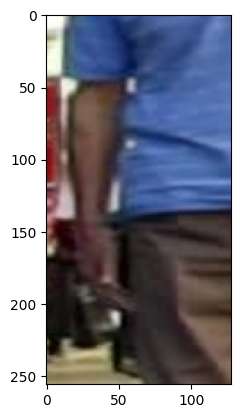

In [65]:
cur_frame = 30
dets_boxes, dets_confs = get_frame_dets(dets, cur_frame)
box = np.array([1857.1,      528.75,      73.775,      181.23])
box = xywh2xyxy(box)
# boxes = dets_boxes[:]

frame_path = get_frame_path(frames_dirpath, cur_frame)
img = cv2.imread(frame_path)

# plot_frame(frame_path, tracks_boxes=[box])
crp = get_object_crop(img, box)

plt.imshow(cv2.cvtColor(crp, cv2.COLOR_BGR2RGB))

In [66]:
last_7_pure_emb = np.array([[  0.0065421,     0.06323,     0.01343,           0,    0.034928,    0.008221,    0.045837,     0.01108,    0.026474,    0.011383,    0.024298,           0,     0.05184,    0.027193,   0.0088606,    0.085533,    0.029519,    0.041786,    0.012253,   0.0068199,   0.0082838,    0.087943,   0.0028929,
           0.080883,   0.0023004,     0.04773,    0.015459,    0.029982,    0.016275,    0.014749,    0.078971,    0.020835,   0.0017859,   0.0023249,  0.00062932,    0.007214,   0.0075718,   0.0013232,    0.050606,    0.024607,    0.030641,    0.042194,    0.021046,     0.11069,     0.05333,   0.0073656,
           0.018592,   0.0011061,    0.017076,  0.00061493,    0.014835,     0.03837,    0.029963,    0.066392,  0.00013677,   0.0057857,    0.032816,    0.017007,    0.052725,    0.010748,    0.033889,    0.014058,    0.064029,    0.048846,    0.079848,   0.0060512,    0.030574,    0.022791,    0.036111,
           0.018559,    0.013805,    0.028081,    0.010036,    0.021863,    0.024823,    0.076191,    0.025576,   0.0083758,    0.012181,    0.021039,     0.01253,    0.015413,    0.019924,   0.0058241,   0.0093485,    0.017933,   0.0045274,     0.06634,    0.036733,    0.017146,   0.0074851,    0.036413,
           0.044681,   0.0015898,    0.036996,   0.0010638,    0.054421,    0.015069,    0.068235,    0.003204,    0.035771,    0.054444,    0.046458,   0.0058828,    0.034722,    0.062841,   0.0046826,    0.069819,    0.043047,   0.0012515,    0.052214,    0.018358,    0.013398,    0.029306,           0,
           0.089779,    0.027223,    0.010282,   0.0070998,  0.00053599,    0.035922,    0.038174,    0.047769,  0.00062668,   0.0080541,    0.039495,    0.053353,    0.027628,   0.0049234,     0.00836,   0.0016497,    0.022914,    0.010789,    0.019286,  3.0504e-06,    0.019703,    0.042475,    0.034598,
          0.0058667,    0.022178,    0.067824,    0.006964,    0.030183,     0.02692,    0.025883,    0.018233,   0.0035569,    0.025101,  0.00066042,   0.0079994,    0.023138,    0.020447,  0.00012161,    0.031822,   0.0084948,     0.11025,  0.00072178,    0.051655,    0.025074,      0.1046,    0.016273,
           0.054483,    0.018404,    0.010014,    0.023622,    0.077778,    0.013903,    0.048965,    0.094202,    0.035164,   0.0028496,   0.0080804,    0.021093,    0.029188,    0.050906,    0.011086,    0.067646,    0.043284,    0.058083,  0.00055543,    0.083034,    0.079773,    0.063927,    0.024707,
           0.061851,    0.057273,    0.038579,    0.065996,    0.068416,    0.022084,     0.04234,   0.0052487,    0.004234,      0.0477,   0.0026783,    0.015631,    0.019788,    0.023281,    0.042585,   0.0052035,    0.019056,    0.028361,    0.044176,    0.027211,     0.07879,    0.065302,    0.017642,
           0.058864,    0.019083,   0.0071871,    0.029251,           0,     0.06884,    0.022139,   0.0068503,     0.02804,    0.036742,    0.033786,    0.038598,  0.00041258,    0.022612,     0.01174,    0.045658,    0.046233,    0.058336,    0.076096,    0.089407,   0.0079741,   0.0013823,    0.029718,
           0.022276,     0.02475,    0.058831,     0.03595,    0.090937,    0.042643,    0.039314,   0.0094903,   0.0090989,      0.0335,     0.03023,    0.052719,    0.019327,    0.027717,    0.029116,           0,    0.030308,    0.014954,    0.018138,    0.018221,    0.020908,    0.054167,    0.070855,
            0.02466,    0.017161,   0.0023071,     0.01091,    0.029482,    0.046251,    0.024883,    0.095116,    0.063082,   0.0026915,     0.02401,   0.0015999,    0.029357,    0.062107,    0.036476,    0.020731,    0.017818,    0.014196,     0.01233,    0.050783,     0.04178,    0.063026,    0.011971,
           0.049119,    0.013632,    0.011831,    0.035077,    0.033127,    0.045151,     0.05789,   0.0047278,    0.049098,    0.054269,    0.055128,     0.07349,    0.083016,    0.025699,    0.017966,    0.012215,    0.013328,     0.02624,   0.0072733,    0.029667,    0.045525,    0.023945,   0.0069949,
           0.019732,    0.030729,     0.06329,    0.011893,    0.034001,    0.036581,    0.014652,    0.015018,    0.084812,    0.042485,    0.048127,   0.0033518,    0.011718,   0.0016921,    0.021523,    0.017038,    0.026791,    0.043045,    0.036283,   0.0088958,    0.073322,    0.080573,    0.029455,
            0.01051,    0.045336,    0.024723,    0.041606,    0.043255,    0.055122,      0.0816,    0.038159,    0.069225,    0.034929,     0.03428,   0.0084996,    0.068592,    0.010882,   0.0085193,    0.016921,    0.048799,     0.05533,    0.078787,    0.061771,    0.045176,     0.03879,    0.057461,
           0.029673,    0.039531,   0.0014093,    0.024667,    0.042319,   0.0029654,  0.00034773,  4.7343e-05,    0.062049,   0.0001769,   0.0065664,    0.018812,    0.047873,    0.054154,    0.017239,    0.030817,    0.016672,   0.0079511,   0.0071192,    0.036513,    0.003703,    0.058857,    0.034704,
           0.073664,     0.04208,    0.031232,    0.010056,    0.055267,   0.0038261,    0.024429,   0.0079653,    0.026773,   0.0018684,    0.034088,           0,     0.04262,    0.039129,     0.05766,    0.033684,    0.034914,     0.10266,   0.0092444,    0.042774,    0.042548,     0.04298,     0.03028,
           0.011318,    0.042884,    0.021129,  0.00029161,    0.042997,    0.035323,    0.047032,    0.031222,    0.012008,    0.036914,    0.008594,    0.032735,      0.0037,    0.020187,    0.014687,    0.020569,     0.03408,    0.015985,    0.063472,    0.070283,    0.029035,   0.0086701,    0.016124,
          0.0094326,   0.0010307,    0.019309,    0.021641,    0.027972,    0.027218,    0.021804,    0.052695,    0.018489,    0.045517,   0.0013716,    0.010039,    0.047244,           0,    0.028024,    0.013594,    0.032481,    0.034501,           0,    0.067512,           0,    0.033327,    0.021949,
           0.041278,    0.031503,     0.11126,    0.029523,    0.024362,    0.041504,    0.012852,  4.1767e-05,   0.0026315,    0.015547,    0.030683,    0.022431,    0.053525,     0.01732,    0.015863,           0,   0.0084465,    0.036129,    0.035582,    0.049754,           0,    0.017566,    0.065321,
          0.0089537,           0,    0.047263,    0.047558,     0.01938,    0.015721,    0.039368,    0.033573,    0.015887,    0.028128,    0.071841,    0.017647,   0.0081408,   0.0011906,    0.010091,    0.049149,    0.018431,    0.022355,    0.037345,    0.020159,    0.025749,      0.0118,    0.030204,
           0.027524,   0.0084963,    0.065699,    0.022654,    0.020079,    0.027339,    0.018174,    0.057493,    0.093943,    0.084553,    0.025545,    0.010621,     0.01248,    0.069188,    0.057223,    0.016747,    0.020518,    0.023074,    0.039366,    0.025648,    0.014136,    0.041341,    0.010604,
                  0,    0.037953,    0.025809,   0.0038342,    0.015343,    0.052186]])

In [68]:
last_7_emb = np.array([[  0.0045007,    0.053539,     0.01731,           0,    0.039714,    0.011138,    0.033577,   0.0083936,    0.019492,    0.013936,     0.02287,           0,    0.040272,    0.023658,   0.0074042,    0.065025,    0.022762,    0.047281,     0.02124,    0.020173,   0.0065513,    0.090225,    0.004731,
           0.062075,    0.002409,    0.035219,    0.021242,    0.021792,    0.028697,    0.010764,    0.077602,    0.025499,   0.0013019,   0.0018447,  0.00043403,    0.019801,   0.0055198,  0.00096461,    0.047229,    0.031093,      0.0333,    0.030827,    0.026417,     0.09447,    0.055754,   0.0053696,
           0.013554,   0.0085891,     0.01275,   0.0011552,    0.015586,    0.050878,    0.026643,    0.069051,  9.9705e-05,   0.0040374,    0.023895,    0.020097,    0.042894,    0.033625,    0.025449,     0.01131,     0.05366,    0.035662,    0.075955,    0.004978,    0.038179,    0.024426,     0.04122,
            0.02604,    0.022233,    0.056322,   0.0085242,    0.022186,    0.017825,    0.076513,    0.025359,   0.0062534,   0.0089183,    0.015874,   0.0092285,    0.013102,    0.019816,    0.013535,    0.016419,    0.013599,   0.0033005,    0.071423,    0.027428,    0.016131,   0.0059454,    0.042512,
           0.042118,   0.0011589,    0.028443,  0.00075943,    0.056382,    0.010843,    0.075247,   0.0023357,     0.02615,    0.051613,    0.038569,   0.0059393,    0.025414,    0.072707,    0.010764,    0.056036,    0.043155,   0.0058126,    0.041945,    0.025626,   0.0095578,    0.022056,   0.0020215,
           0.086517,    0.028645,    0.018081,     0.02564,   0.0031809,    0.026056,    0.037019,    0.059653,  0.00062978,    0.010454,    0.028853,    0.042873,    0.020166,   0.0038096,    0.010025,   0.0065936,    0.027559,   0.0091182,    0.018862,   0.0016693,    0.025318,     0.04397,    0.045247,
          0.0046944,    0.028928,    0.070079,    0.011332,    0.043136,    0.040839,    0.021635,    0.013088,   0.0039324,    0.026742,  0.00048144,   0.0058316,    0.016983,    0.014834,  8.8653e-05,    0.036705,   0.0083528,    0.085411,   0.0077552,    0.038506,    0.019715,     0.12041,    0.011401,
           0.078254,    0.019679,     0.00748,    0.021683,    0.058172,    0.026537,    0.048302,    0.088494,    0.025717,   0.0026893,   0.0068654,    0.039128,    0.031703,     0.03711,    0.013262,    0.077467,    0.031613,    0.053042,  0.00040491,    0.063779,    0.083539,    0.052975,    0.023571,
           0.045487,    0.041637,    0.032713,    0.058761,    0.062042,    0.015993,    0.049993,   0.0072808,    0.010685,    0.044237,   0.0025858,    0.016304,    0.024017,    0.016973,    0.051699,   0.0089245,    0.018021,    0.026304,    0.051406,    0.020332,    0.092065,    0.056621,    0.015298,
           0.063028,    0.042655,   0.0058262,    0.044211,           0,    0.065595,    0.022533,   0.0046788,    0.020496,    0.046496,    0.029316,    0.049199,  0.00030077,    0.016905,   0.0085516,    0.063111,    0.053197,    0.056518,    0.072698,    0.069691,     0.02663,   0.0010077,    0.031856,
           0.016239,    0.017946,    0.044085,    0.026427,    0.084723,    0.040137,    0.031055,     0.01382,   0.0089524,    0.037244,     0.03018,    0.049372,    0.014244,    0.047089,    0.030045,           0,    0.022205,    0.029837,    0.013343,    0.016094,    0.035033,    0.070674,    0.058022,
           0.024144,    0.019467,   0.0097099,   0.0079535,    0.029404,    0.034116,    0.018258,    0.099631,    0.080234,   0.0020989,     0.02053,   0.0011663,    0.025757,    0.055818,    0.026504,    0.038777,    0.016697,    0.027588,   0.0089887,    0.043331,    0.048962,    0.052936,   0.0087254,
            0.04536,    0.010175,    0.010584,    0.025374,    0.024057,    0.046301,    0.042291,   0.0080346,     0.04372,    0.046308,    0.040354,    0.060895,    0.093795,    0.027305,    0.018782,   0.0087683,    0.026114,    0.022165,    0.017998,    0.040027,    0.033578,    0.020189,      0.0113,
           0.026744,    0.022383,    0.051534,    0.029422,    0.037107,     0.03339,     0.01367,    0.011169,     0.12529,    0.050483,    0.043418,   0.0076162,   0.0087495,   0.0054364,    0.015938,    0.012257,    0.022714,    0.036428,     0.03636,     0.01087,    0.085379,    0.076024,    0.038886,
           0.014404,    0.036277,    0.018476,    0.031082,     0.03188,    0.044025,    0.060342,    0.027864,    0.074905,    0.033181,    0.034409,    0.006354,    0.053889,    0.011355,   0.0064154,     0.01875,    0.048504,     0.05899,    0.061703,    0.053123,    0.046406,    0.028226,    0.041886,
           0.029148,    0.035952,   0.0090717,    0.030235,    0.048073,   0.0021618,   0.0033472,   0.0015267,    0.056021,  0.00012896,   0.0047869,    0.036635,    0.034975,    0.053681,    0.024914,     0.02635,    0.033187,   0.0065546,   0.0051017,    0.026791,    0.016432,    0.056753,    0.025462,
           0.080038,    0.041231,    0.037539,   0.0096883,    0.041324,   0.0025509,     0.02482,     0.01594,    0.019612,   0.0014322,    0.031479,   0.0034261,    0.030805,    0.028555,     0.06635,    0.028235,     0.03878,    0.098618,   0.0066928,    0.049102,    0.036498,    0.044906,    0.038839,
           0.027756,    0.033993,    0.030847,  0.00052638,    0.044772,    0.037091,    0.054487,    0.054029,    0.014127,    0.047578,    0.018815,    0.026749,   0.0029719,    0.014658,    0.023075,    0.036098,    0.048613,    0.020118,    0.069517,    0.068092,    0.037709,    0.016743,    0.018512,
          0.0097257,  0.00075137,    0.021198,    0.024777,    0.021246,    0.039896,    0.026754,    0.041114,    0.013479,    0.035196,   0.0020078,    0.028022,    0.042042,   0.0047991,     0.02833,    0.010864,    0.023679,    0.026404,           0,    0.054005,           0,    0.030332,    0.019423,
           0.036355,    0.027403,    0.081939,    0.030708,    0.023628,    0.035342,   0.0095847,  3.0448e-05,   0.0099027,    0.011323,    0.025989,     0.01611,    0.045434,    0.021759,    0.012274,           0,   0.0061575,     0.03006,    0.032882,    0.036777,           0,    0.014464,    0.068404,
            0.02263,           0,    0.037977,    0.050215,     0.01387,    0.018798,    0.046524,    0.033636,    0.018627,     0.03641,    0.057473,    0.018511,    0.022151,  0.00078631,   0.0077032,    0.054293,    0.018448,    0.016699,    0.049062,    0.015898,    0.041045,    0.008736,    0.025051,
           0.022674,   0.0060815,    0.064268,    0.018623,    0.037263,    0.025648,     0.02196,    0.044346,    0.068957,    0.092244,    0.038707,   0.0077425,    0.019413,    0.058252,    0.054256,    0.021427,    0.020119,    0.022056,    0.045672,     0.02248,    0.022146,    0.030082,    0.019874,
                  0,    0.043849,    0.018749,   0.0026366,    0.025037,    0.059913]])

In [76]:
det_emb = np.array([[   0.012699,    0.040059,   0.0067878,           0,    0.075884,    0.063793,   0.0097116,    0.010245,    0.028549,           0,    0.045996,           0,           0,           0,           0,    0.020118,    0.068231,    0.061404,    0.047862,           0,    0.026915,    0.064752,    0.060361,
           0.013628,    0.031281,    0.037271,    0.011804,    0.073452,   0.0015043,    0.009603,     0.10285,    0.051565,           0,    0.017876,           0,     0.10843,   0.0031836,    0.032147,    0.044465,    0.026948,     0.03993,  7.0851e-05,    0.072389,    0.041794,    0.061944,    0.020816,
         0.00072267,    0.070581,    0.011125,           0,    0.002348,     0.01012,    0.041096,    0.072471,    0.043025,   0.0012638,      0.0386,    0.026982,     0.03782,    0.027666,    0.040369,   0.0057941,    0.064321,    0.019524,    0.064133,    0.041212,    0.025327,   0.0084766,    0.029321,
           0.040368,    0.035354,    0.052175,    0.049738,   0.0066085,    0.015903,    0.050098,    0.044264,   0.0098491,   0.0096887,    0.042046,    0.026709,    0.060832,   0.0091915,           0,   0.0042453,    0.028765,           0,    0.059302,     0.10375,    0.029849,    0.052527,     0.04764,
           0.030321,   0.0053198,    0.024072,    0.029216,    0.068285,           0,    0.045706,   0.0012218,    0.042937,    0.070955,    0.055865,    0.020554,   0.0066063,    0.080505,    0.060871,    0.027402,    0.056743,   0.0021361,     0.02175,    0.028077,    0.038375,   0.0023207,    0.017873,
           0.066174,    0.027439,    0.048138,    0.032071,           0,    0.068572,    0.029161,    0.035564,    0.018679,    0.046337,           0,    0.023851,           0,     0.03816,    0.021654,    0.041452,    0.060652,    0.012345,    0.080036,           0,           0,    0.020306,    0.029638,
           0.022958,    0.026743,    0.068463,           0,    0.044002,    0.024052,           0,           0,           0,    0.012777,   0.0035584,           0,    0.027925,   0.0098644,    0.018987,    0.058924,    0.042147,     0.08934,    0.034445,    0.033795,    0.019942,      0.1573,    0.027542,
           0.081448,    0.034683,    0.021268,    0.060339,    0.087308,    0.038592,     0.03875,     0.11391,    0.012521,   0.0014359,  0.00026697,    0.017719,    0.017473,           0,    0.018057,    0.089172,      0.0509,    0.084764,           0,    0.079035,     0.07564,     0.01725,    0.012385,
           0.048696,    0.010297,    0.091987,    0.038313,    0.067484,     0.01452,    0.061236,    0.023354,    0.025213,    0.048764,     0.03941,    0.012222,    0.012508,    0.015802,   0.0029289,    0.037459,    0.019655,    0.020471,    0.063948,     0.01215,     0.12598,    0.047269,    0.024696,
          0.0038537,    0.092129,     0.02143,    0.057301,           0,     0.06187,     0.03709,      0.0201,    0.043044,    0.047672,    0.021437,    0.062078,   0.0059978,    0.029397,    0.040306,    0.045681,    0.043586,    0.051003,    0.058097,    0.077886,    0.016893,   0.0063917,    0.052804,
                  0,    0.027616,    0.010175,   0.0049069,    0.071483,    0.014346,    0.024287,    0.048238,    0.083633,    0.058616,   0.0023514,    0.035875,           0,    0.047524,    0.012257,           0,    0.050324,    0.052538,    0.047083,    0.025065,    0.087082,    0.094593,   0.0070607,
            0.10098,    0.031198,    0.003834,    0.031033,    0.007486,   0.0089391,   0.0097667,    0.077481,     0.11505,    0.014553,    0.013061,           0,    0.028659,    0.071201,    0.024917,    0.053609,     0.01875,    0.066465,    0.014987,    0.027773,     0.01787,    0.049496,    0.029066,
           0.028869,   0.0057225,    0.016734,    0.042714,    0.051143,    0.040436,    0.028905,    0.016604,    0.062266,    0.018349,      0.0198,    0.025619,      0.0961,    0.065237,    0.017314,    0.019501,     0.01967,    0.013764,    0.035103,    0.021043,           0,    0.072355,    0.026732,
           0.041922,    0.024441,           0,    0.042516,    0.026496,    0.016685,    0.045074,    0.010255,     0.18198,    0.056424,     0.11907,           0,    0.057541,           0,    0.030295,   0.0083521,    0.079243,    0.068259,    0.066937,     0.03014,     0.13333,    0.035938,    0.039966,
           0.060342,    0.059552,    0.019716,   0.0016724,    0.033697,    0.042848,    0.020887,   0.0071941,    0.075945,    0.035036,    0.039701,           0,    0.058593,    0.042073,           0,    0.058742,     0.06473,    0.068484,    0.062259,    0.058824,    0.056465,    0.014658,    0.041241,
                  0,   0.0014892,           0,   0.0098709,    0.074477,   0.0052272,           0,           0,     0.05092,    0.017836,    0.017905,    0.049377,   0.0092938,    0.050289,    0.047794,    0.023463,    0.015394,    0.009993,           0,    0.062209,           0,    0.077399,    0.013538,
           0.070215,    0.016674,    0.031209,    0.014605,    0.010548,           0,    0.043992,    0.022186,    0.038826,    0.017769,    0.057964,           0,           0,   0.0013513,   0.0086703,    0.025078,           0,    0.086795,    0.053221,    0.042739,    0.070272,    0.067241,    0.053551,
           0.030217,    0.043249,    0.027217,    0.023286,    0.046178,    0.045989,    0.087539,    0.039548,           0,    0.021313,   0.0011125,    0.055399,    0.011458,           0,    0.036189,    0.045226,    0.033873,     0.02785,       0.059,    0.066327,    0.031106,     0.04193,    0.024086,
           0.029733,    0.018797,    0.070388,    0.038859,    0.033738,    0.078882,   0.0020765,           0,      0.0132,    0.076169,   0.0092114,    0.031383,    0.082688,           0,    0.056439,    0.017246,    0.024914,           0,           0,   0.0062075,           0,           0,    0.038497,
           0.018964,    0.041609,    0.074691,    0.086359,    0.034596,    0.014825,           0,    0.015978,    0.029464,    0.022447,     0.01608,     0.03361,    0.017915,    0.013563,     0.01226,  0.00087711,           0,    0.023278,    0.052301,    0.055049,  0.00018061,    0.010988,    0.098139,
           0.077311,           0,    0.065415,    0.061518,    0.028773,    0.043166,     0.01572,    0.021994,   0.0054396,    0.091712,    0.063352,   0.0063051,   0.0088365,   0.0034856,    0.042413,    0.051762,   0.0010279,    0.051504,    0.078273,    0.014087,           0,    0.014354,    0.009894,
           0.034998,           0,   0.0098367,    0.051722,    0.037302,    0.078479,    0.047799,     0.01676,    0.045996,     0.11622,    0.048408,           0,    0.065291,     0.06211,    0.030941,    0.022651,   0.0063115,    0.021694,    0.034498,    0.016741,           0,    0.017199,    0.034313,
            0.01597,    0.051567,           0,    0.021795,    0.045178,    0.047227]])

In [79]:
cdist(last_7_emb, det_emb, metric="cosine") / 2

array([[0.07856521]])

423 395 611 850


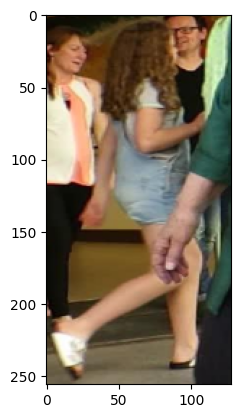

In [63]:
cur_frame = 175
box = np.array([517.39,       623.2,      187.22,      455.03])
box = xywh2xyxy(box)
# boxes = dets_boxes[:]

frame_path = get_frame_path(frames_dirpath, cur_frame)
img = cv2.imread(frame_path)

# plot_frame(frame_path, tracks_boxes=[box])
crp = get_object_crop(img, box)

plt.imshow(cv2.cvtColor(crp, cv2.COLOR_BGR2RGB))

In [17]:
dets_boxes

array([[1441,  376, 1612,  752],
       [1661,  525, 1778,  731],
       [1268,  384, 1389,  739],
       [1583,  414, 1690,  704],
       [1143,  397, 1285,  726],
       [1691,  399, 1800,  662],
       [1351,  374, 1452,  717],
       [1445,  371, 1564,  712],
       [1531,  416, 1644,  680],
       [1424,  406, 1513,  691],
       [1887,  434, 1949,  616],
       [1443,  388, 1532,  694],
       [ 795,  452,  892,  719]])

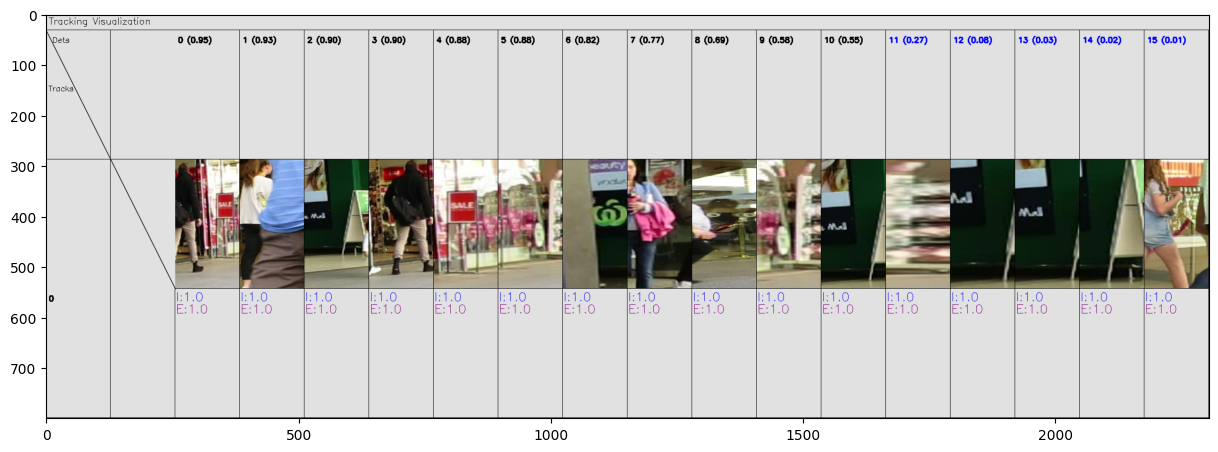

In [32]:
cur_frame = 206

dets = load_dets(dets_path)
img = cv2.imread(get_frame_path(frames_dirpath, cur_frame))
# tracks_boxes, tracks_ids = get_frame_tracks(frames_dirpath, tracks_dirpath, cur_frame)
dets_boxes, dets_confs = get_frame_dets(dets, cur_frame)


tracks_boxes = np.array([[    -177.93,      676.89,      352.72,      1145.1],])


iou_dists = np.ones((len(tracks_boxes), len(dets_boxes)))

t_img, *_ = visualize_tracking(img, tracks_boxes, xyxy2xywh(dets_boxes), dets_confs, iou_dists)

plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(t_img, cv2.COLOR_BGR2RGB))

In [48]:
tracks_boxes

array([[9.60000000e-05, 2.28786120e+02, 1.02555168e+02, 1.07684316e+03],
       [8.59801728e+02, 4.11914160e+02, 1.04120563e+03, 7.95780720e+02],
       [1.64959411e+03, 4.02060240e+02, 1.76126285e+03, 6.48470880e+02],
       [1.60112640e+02, 0.00000000e+00, 8.99923200e+02, 1.08000000e+03],
       [6.56952576e+02, 3.84822900e+02, 8.20725504e+02, 7.93904220e+02],
       [9.84416640e+02, 3.33206460e+02, 1.18771776e+03, 7.95171060e+02],
       [1.42557888e+03, 4.35676860e+02, 1.53108672e+03, 6.92227620e+02],
       [1.41331690e+03, 5.36420340e+02, 1.48042646e+03, 6.97974300e+02],
       [1.52909059e+03, 4.26376980e+02, 1.64715773e+03, 6.57634140e+02],
       [4.74999360e+02, 3.77586900e+02, 6.89085120e+02, 8.62961580e+02],
       [5.49554880e+02, 3.76286040e+02, 7.49386560e+02, 8.23010760e+02]])

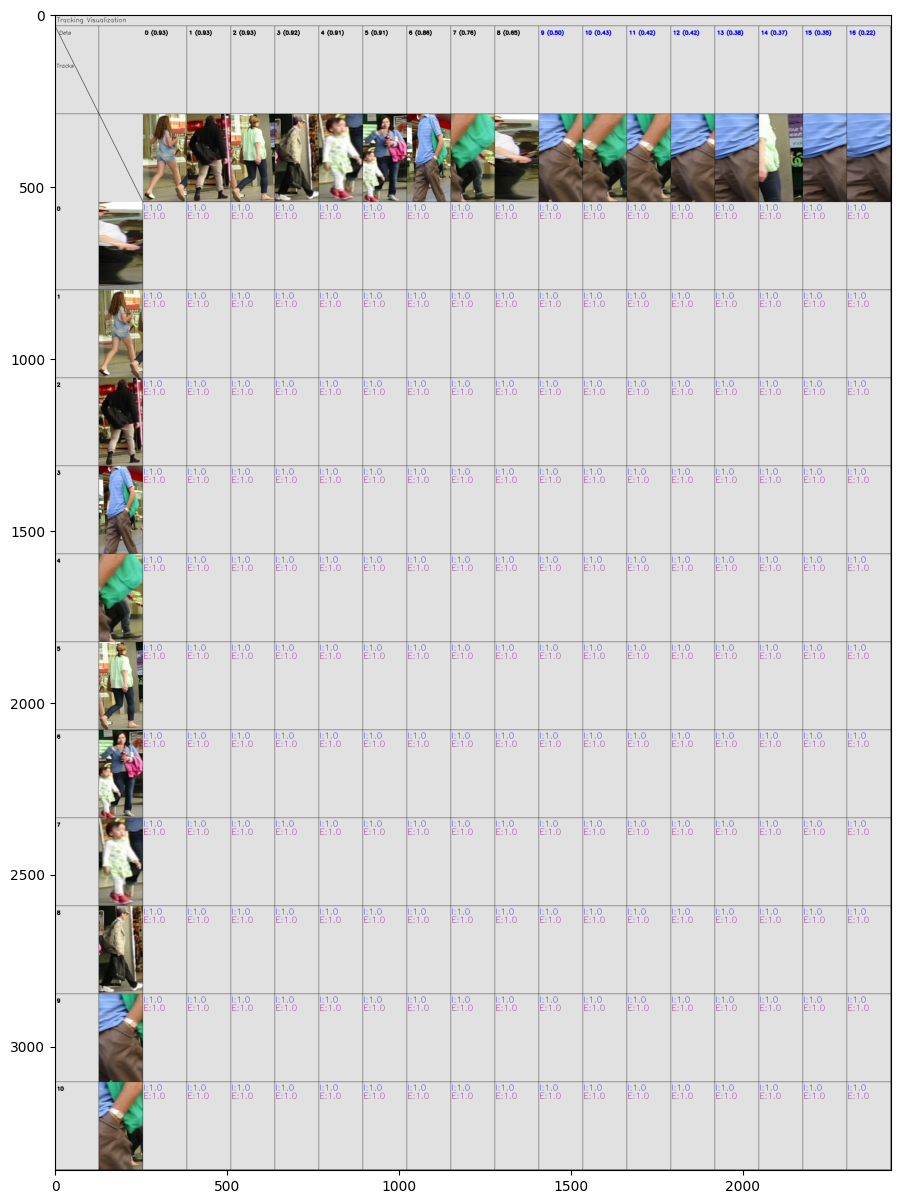

In [35]:
i = 2

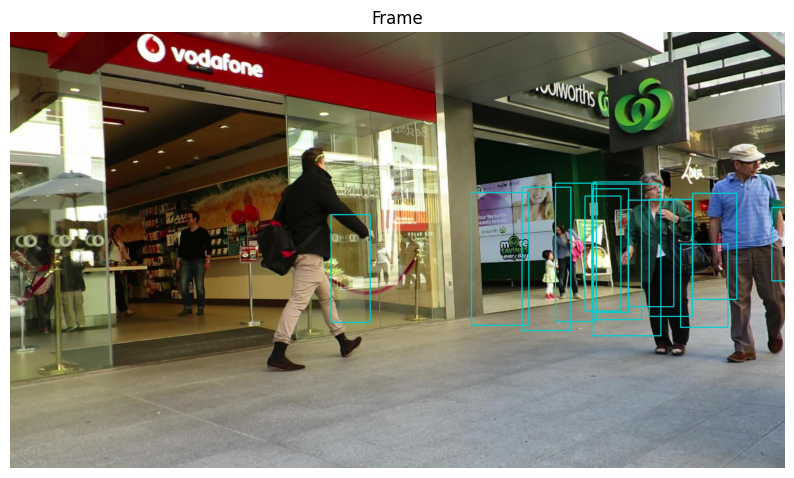

In [27]:
plot_debug_frame(frames_dirpath, 66, plot_tracks=False)

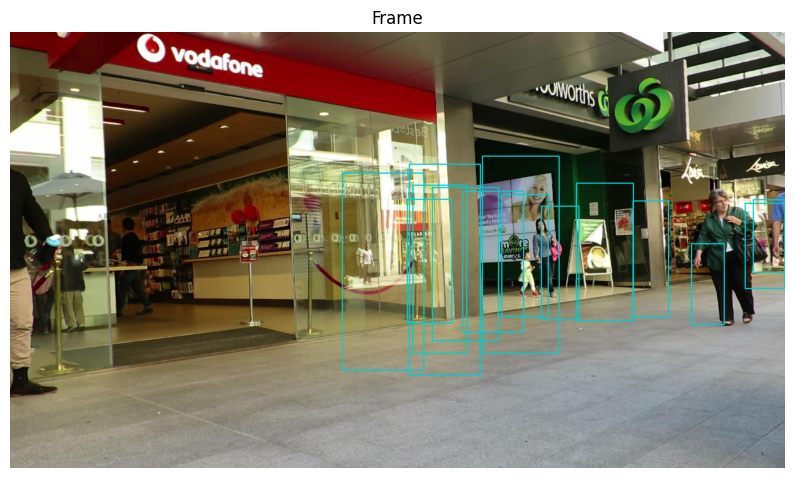

In [37]:
plot_debug_frame(frames_dirpath, i, plot_tracks=False)
i += 1

In [1]:
import numpy as np

In [20]:
a = [[[595.012512389323, 446.1750183105469, 618.6375120247395, 510.9750061035156, 27.0, 0.4782969000000001]], [[1102.9500734240057, 444.1500244140625, 1138.0500486463068, 540.6749877929688, 26.0, 0.4782969000000001]], [[393.8625184886291, 461.70001220703125, 428.96252423598025, 560.25, 25.0, 0.4782969000000001]], [[806.6250001512608, 445.1625061035156, 830.9250486768642, 525.4874877929688, 24.0, 0.4782969000000001]], [[1013.1750490133103, 455.9625244140625, 1040.1750486429398, 528.8624877929688, 23.0, 0.4782969000000001]], [[1115.7750246007292, 446.8500061035156, 1153.5750730555208, 548.1000366210938, 22.0, 0.4782969000000001]], [[437.0625001847828, 457.6500244140625, 471.4875181257641, 550.7999877929688, 21.0, 0.4782969000000001]], [[1571.400024612738, 406.3500061035156, 1733.400024215387, 814.050048828125, 20.0, 0.4782969000000001]], [[501.18753067204966, 462.0375061035156, 526.837524259591, 545.0625, 19.0, 0.4782969000000001]], [[596.0250246294474, 441.1125183105469, 614.92504861274, 484.9875183105469, 18.0, 0.4782969000000001]], [[988.8750612131222, 450.5625, 1017.2250364431278, 530.2125244140625, 17.0, 0.4782969000000001]], [[843.0750123736982, 449.88751220703125, 864.675048661458, 514.6875, 16.0, 0.4782969000000001]], [[415.4625246095752, 465.7500305175781, 456.63751201151854, 571.050048828125, 15.0, 0.4782969000000001]], [[558.562500179348, 456.9750061035156, 580.8375242347145, 519.0750122070312, 14.0, 0.4782969000000001]], [[626.0625001739132, 457.3125, 647.6625364471805, 519.4125366210938, 13.0, 0.4782969000000001]], [[1633.5000001737892, 415.125, 1798.2000730683983, 888.9750366210938, 12.0, 0.4782969000000001]], [[536.6250001875003, 457.6500244140625, 558.9000242265622, 517.0499877929688, 11.0, 0.4782969000000001]], [[598.7250368138648, 457.6500244140625, 620.3250120142602, 513.6749877929688, 10.0, 0.4782969000000001]], [[579.487549003949, 456.3000183105469, 601.0875242382385, 517.7250366210938, 9.0, 0.4782969000000001]], [[1025.32507341273, 427.2750244140625, 1173.825073071645, 862.6500244140625, 8.0, 0.4782969000000001]], [[1171.8000490386512, 449.2125244140625, 1214.9999997894738, 551.8125, 7.0, 0.4782969000000001]], [[1368.9000245718353, 418.5, 1460.7000730844147, 709.425048828125, 6.0, 0.4782969000000001]], [[383.4000245989109, 464.7375183105469, 424.5750120221829, 576.112548828125, 5.0, 0.4782969000000001]], [[773.5500490018954, 444.1500244140625, 845.1000364473233, 650.0250244140625, 4.0, 0.4782969000000001]], [[1011.1500245454091, 411.75, 1171.8000486967785, 1023.300048828125, 3.0, 0.4782969000000001]], [[508.61251846439296, 456.3000183105469, 541.0125120531851, 561.6000366210938, 2.0, 0.4782969000000001]], [[889.6500245463582, 422.5500183105469, 1027.349975453642, 942.9750671386719, 1.0, 0.4782969000000001]]]

In [6]:
a[0]

[[595.012512389323,
  446.1750183105469,
  618.6375120247395,
  510.9750061035156,
  27.0,
  0.4782969000000001]]

In [28]:
b = [[889.6500241322957, 422.550018, 1027.3499758677044, 942.975037, 1.0, 0.4782969000000001, -1.0, -1.0], [508.61251815384617, 456.300018, 541.012511846154, 561.600037, 2.0, 0.4782969000000001, -1.0, -1.0], [1011.1500241313466, 411.75, 1171.8000488686534, 1023.299988, 3.0, 0.4782969000000001, -1.0, -1.0], [773.5499881737705, 444.14999399999994, 845.1000368262294, 650.025024, 4.0, 0.4782969000000001, -1.0, -1.0], [383.3999941848486, 464.7375180000001, 424.5750118151514, 576.112488, 5.0, 0.4782969000000001, -1.0, -1.0], [1368.9000241577728, 418.5, 1460.7000728422272, 709.424988, 6.0, 0.4782969000000001, -1.0, -1.0], [1171.800049210526, 449.212494, 1214.999999789474, 551.8125, 7.0, 0.4782969000000001, -1.0, -1.0], [1025.3250731705425, 427.27499399999994, 1173.8250728294574, 862.650024, 8.0, 0.4782969000000001, -1.0, -1.0], [579.4874881758244, 456.300018, 601.0875238241756, 517.725037, 9.0, 0.4782969000000001, -1.0, -1.0], [598.7250371927709, 457.649994, 620.3250118072291, 513.674988, 10.0, 0.4782969000000001, -1.0, -1.0], [536.6250001875002, 457.649994, 558.9000238124999, 517.049988, 11.0, 0.4782969000000001, -1.0, -1.0], [1633.5000001737892, 415.12500000000006, 1798.2000728262108, 888.9750370000002, 12.0, 0.4782969000000001, -1.0, -1.0], [626.0625001739132, 457.3125, 647.6625368260869, 519.412537, 13.0, 0.4782969000000001, -1.0, -1.0], [558.562500179348, 456.975006, 580.837523820652, 519.075012, 14.0, 0.4782969000000001, -1.0, -1.0], [415.46249419551293, 465.75, 456.6375118044871, 571.049988, 15.0, 0.4782969000000001, -1.0, -1.0], [843.0750121666665, 449.887512, 864.6749878333335, 514.6875, 16.0, 0.4782969000000001, -1.0, -1.0], [988.8750001779663, 450.5625, 1017.2250368220339, 530.212524, 17.0, 0.4782969000000001, -1.0, -1.0], [596.0250242153842, 441.112518, 614.9249877846158, 484.987518, 18.0, 0.4782969000000001, -1.0, -1.0], [501.1875001544717, 462.037506, 526.8375238455284, 545.0625, 19.0, 0.4782969000000001, -1.0, -1.0], [1571.4000241986755, 406.35000599999995, 1733.4000238013246, 814.049988, 20.0, 0.4782969000000001, -1.0, -1.0], [437.0625001847827, 457.649994, 471.4875178152173, 550.799988, 21.0, 0.4782969000000001, -1.0, -1.0], [1115.7750241866668, 446.850006, 1153.5750728133332, 548.100037, 22.0, 0.4782969000000001, -1.0, -1.0], [1013.1749881851857, 455.962494, 1040.1750488148145, 528.862488, 23.0, 0.4782969000000001, -1.0, -1.0], [806.6250001512605, 445.162506, 830.9249878487395, 525.487488, 24.0, 0.4782969000000001, -1.0, -1.0], [393.8625181780821, 461.700012, 428.9624938219179, 560.25, 25.0, 0.4782969000000001, -1.0, -1.0], [1102.950073181818, 444.149994, 1138.050048818182, 540.674988, 26.0, 0.4782969000000001, -1.0, -1.0], [595.0125121822917, 446.175018, 618.6375118177083, 510.975006, 27.0, 0.4782969000000001, -1.0, -1.0]]

In [22]:
np.array(a).shape

(27, 1, 6)

In [33]:
bb = np.array(b)
bb.reshape(bb.shape[0], 1, -1).shape

(27, 1, 8)

In [14]:
aa = sorted(a, key=lambda x: x[4])
bb = sorted(b, key=lambda x: x[4])

IndexError: list index out of range

In [ ]:
def check_trackers(file_a, file_b, make_int: bool = True, ignore_xyz: bool = True):
    arra = np.loadtxt(file_a, delimiter=",")
    arrb = np.loadtxt(file_b, delimiter=",")

    frames_cnt = int(np.max(arra[:, 0]))

    for i in range(1, frames_cnt + 1):
        arra_check = arra[arra[:, 0] == i]
        arrb_check = arrb[arrb[:, 0] == i]

        arra_check = arra_check[arra_check[:, 1].argsort()][:, [0, 2, 3, 4, 5, 6, 7, 8]]
        arrb_check = arrb_check[arrb_check[:, 1].argsort()][:, [0, 2, 3, 4, 5, 6, 7, 8]]

        if make_int:
            arra_check[:-1] = arra_check[:-1].round().astype(np.int32)
            arrb_check[:-1] = arrb_check[:-1].round().astype(np.int32)

        if ignore_xyz:
            arra_check = arra_check[:, :-3]
            arrb_check = arrb_check[:, :-3]

        if arra_check.shape == arrb_check.shape and np.allclose(arra_check, arrb_check, atol=1):
            pass
        else:
            print(f"Not equal: {i}")
            print(arra_check.shape, arrb_check.shape)

            shape = arra_check.shape[0]
            
            if arra_check.shape != arrb_check.shape:
                print(arra_check)
                print(arrb_check)
                
            else:

                for j in range(shape):
                    if not np.allclose(arra_check[j], arrb_check[j], atol=1):
                        print(arra_check[j])
                        print(arrb_check[j])

            raise ValueError
    
    return True

In [102]:
check_trackers(
    '/home/kozakmv/Programming/Python/boosttrack/results/trackers/MOT17-val/bt/data/MOT17-05-FRCNN.txt',
    '/home/kozakmv/Programming/Python/boxmot/runs/mot/yolox_x_byte_osnet_x1_0_msmt17_boosttrack_5/MOT17-05.txt')

Not equal: 1
(5, 5) (5, 5)
[  1. 159. 166.  51. 137.] [  1.8 286.2 298.8  91.8 246.6]
[  1. 357. 373. 114. 308.]
[  1. 205. 164.  50. 138.] [  1.8 369.  295.2  90.  248.4]
[  1. 461. 370. 113. 310.]
[  1. 511.  28. 159. 423.] [  1.8 919.8  50.4 286.2 761.4]
[1.000e+00 1.149e+03 6.200e+01 3.580e+02 9.510e+02]
[  1. 295. 188.  28.  78.] [  1.8 531.  338.4  50.4 140.4]
[  1. 664. 424.  63. 175.]
[  1.  287.4 192.3  24.9  69.6] [  1.8  517.32 346.14  44.82 125.28]
[  1. 647. 433.  56. 157.]


ValueError: 

In [59]:
a = [ 1.0000e+00,  5.7950e+02,  4.5630e+02,  2.1600e+01,  6.1400e+01,  4.8000e-01,
  -1.0000e+00, -1.0000e+00]

In [60]:
np.round(a)

array([  1., 580., 456.,  22.,  61.,   0.,  -1.,  -1.])

In [4]:
def convert_x_to_bbox(x, score=None):
    """
    Converts a state vector [x, y, h, r] back to bounding box [x1,y1,x2,y2].
    """
    h = x[2]
    r = x[3]
    w = 0 if r <= 0 else r * h
    if score is None:
        return np.array([x[0] - w / 2.0, x[1] - h / 2.0,
                         x[0] + w / 2.0, x[1] + h / 2.0]).reshape((1, 4))
    else:
        return np.array([x[0] - w / 2.0, x[1] - h / 2.0,
                         x[0] + w / 2.0, x[1] + h / 2.0, score]).reshape((1, 5))

In [2]:
def original_camera_update(boxes: np.ndarray, transform: np.ndarray) -> np.ndarray:
    new_boxes = []
    for box in boxes:
        x1, y1, x2, y2 = convert_x_to_bbox(box)[0]
        x1_, y1_, _ = transform @ np.array([x1, y1, 1]).T
        x2_, y2_, _ = transform @ np.array([x2, y2, 1]).T
        w, h = x2_ - x1_, y2_ - y1_
        cx, cy = x1_ + w / 2, y1_ + h / 2
        new_boxes.append([cx, cy, h, w / h])
    return np.array(new_boxes)

In [3]:
def batch_camera_update(boxes: np.ndarray, transform: np.ndarray) -> np.ndarray:
    """
    Batched version of camera_update that processes all boxes at once.
    
    Args:
        boxes: Array of boxes in [x_center, y_center, width, height] format with shape [B, 4]
        transform: Transformation matrix with shape [3, 3]
    
    Returns:
        Updated boxes in the same [x_center, y_center, width, height] format with shape [B, 4]
    """
    batch_size = boxes.shape[0]
    
    # Extract components
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    
    # Calculate corners for each box
    half_w = w / 2
    half_h = h / 2
    
    # Calculate all corners for all boxes at once
    # For each box, calculate its 4 corners
    x1 = cx - half_w  # top-left x
    y1 = cy - half_h  # top-left y
    x2 = cx + half_w  # bottom-right x
    y2 = cy + half_h  # bottom-right y
    
    # Create all corners as homogeneous coordinates [batch_size, 4, 3]
    corners = np.zeros((batch_size, 4, 3))
    
    # Populate corners: top-left, top-right, bottom-right, bottom-left
    corners[:, 0, :] = np.column_stack([x1, y1, np.ones(batch_size)])  # top-left
    corners[:, 1, :] = np.column_stack([x2, y1, np.ones(batch_size)])  # top-right
    corners[:, 2, :] = np.column_stack([x2, y2, np.ones(batch_size)])  # bottom-right
    corners[:, 3, :] = np.column_stack([x1, y2, np.ones(batch_size)])  # bottom-left
    
    # Reshape to apply transform to all corners at once
    corners_flat = corners.reshape(-1, 3)  # [B*4, 3]
    
    # Apply transform
    corners_trans_flat = corners_flat @ transform.T  # [B*4, 3]
    
    # Reshape back
    corners_trans = corners_trans_flat.reshape(batch_size, 4, 3)  # [B, 4, 3]
    
    # Extract transformed coordinates
    trans_x = corners_trans[:, :, 0]  # [B, 4]
    trans_y = corners_trans[:, :, 1]  # [B, 4]
    
    # Calculate new bounding box dimensions
    new_x1 = np.min(trans_x, axis=1)
    new_y1 = np.min(trans_y, axis=1)
    new_x2 = np.max(trans_x, axis=1)
    new_y2 = np.max(trans_y, axis=1)
    
    # Compute new centers and dimensions
    new_w = new_x2 - new_x1
    new_h = new_y2 - new_y1
    new_cx = new_x1 + new_w / 2
    new_cy = new_y1 + new_h / 2
    
    # Return in [x_center, y_center, width, height] format
    return np.stack([new_cx, new_cy, new_w, new_h], axis=1)

In [5]:
def xcycwh_to_xcychr(boxes: np.ndarray) -> np.ndarray:
    """
    Convert batched boxes from [xc, yc, w, h] to [xc, yc, h, ratio].

    Args:
        boxes (np.ndarray): Array of shape [B, 4] with each row as [xc, yc, w, h].

    Returns:
        np.ndarray: Array of shape [B, 4] with each row as [xc, yc, h, ratio].
    """
    xc, yc, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    ratio = w / h
    converted_boxes = np.stack([xc, yc, h, ratio], axis=1)
    return converted_boxes

def xcychr_to_xcycwh(boxes: np.ndarray) -> np.ndarray:
    """
    Convert batched boxes from [xc, yc, h, ratio] to [xc, yc, w, h].

    Args:
        boxes (np.ndarray): Array of shape [B, 4] with each row as [xc, yc, h, ratio].

    Returns:
        np.ndarray: Array of shape [B, 4] with each row as [xc, yc, w, h].
    """
    xc, yc, h, ratio = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    w = ratio * h
    converted_boxes = np.stack([xc, yc, w, h], axis=1)
    return converted_boxes

In [6]:
boxes = np.array([
    [120, 240, 50, 50],
    [100, 124, 30, 90],
    [240, 120, 65, 40]
])

boxes_xcychr = xcycwh_to_xcychr(boxes)

transform = np.array([
    [0.8, 0.2, 0.1],
    [0.2, 1.0, 0.3],
    [0.05, 0, 0.9]
])

In [7]:
xcychr_to_xcycwh(original_camera_update(boxes_xcychr, transform))


array([[144.1, 264.3,  50. ,  60. ],
       [104.9, 144.3,  42. ,  96. ],
       [216.1, 168.3,  60. ,  53. ]])

In [8]:
batch_camera_update(boxes, transform)

array([[144.1, 264.3,  50. ,  60. ],
       [104.9, 144.3,  42. ,  96. ],
       [216.1, 168.3,  60. ,  53. ]])

In [9]:
import time

In [12]:
check_times = 1000
boxes_size = 30

boxes = np.random.rand(boxes_size, 4)
boxes_xcychr = xcycwh_to_xcychr(boxes)
transform = np.random.rand(3, 3)

start_time = time.time()
for _ in range(check_times):
    original_camera_update(boxes_xcychr, transform)
end_time = time.time()

print(f"Original camera update: {end_time - start_time:.4f} seconds")

start_time = time.time()
for _ in range(check_times):
    batch_camera_update(boxes, transform)
end_time = time.time()

print(f"Batch camera update: {end_time - start_time:.4f} seconds")


Original camera update: 0.1525 seconds
Batch camera update: 0.0317 seconds


In [3]:
last_clean_emb = np.array([          0,    0.022482,           0,           0,    0.011105,    0.084398,    0.011705,           0,           0,           0,    0.031663,           0,    0.043489,    0.012509,    0.017999,    0.071845,    0.089237,   0.0087399,           0,           0,    0.019492,           0,    0.056996,    0.033883,
         0.0018405,    0.048469,           0,    0.041753,           0,           0,    0.082227,           0,           0,           0,    0.020125,    0.045839,    0.022963,           0,     0.15339,           0,    0.010074,    0.018647,    0.060557,    0.007692,    0.036313,           0,           0,           0,
                 0,     0.01236,    0.016674,           0,   0.0087739,    0.065829,    0.018497,     0.02089,    0.031969,    0.016378,    0.037375,           0,     0.12184,           0,    0.042319,   0.0078491,     0.14248,   0.0098779,    0.013478,           0,           0,   0.0054662,    0.032215,           0,
                 0,    0.017358,     0.12215,    0.072825,    0.060389,   0.0010035,    0.016359,    0.068506,      0.0242,     0.03068,    0.011026,           0,    0.013751,    0.054357,           0,           0,    0.052846,    0.015454,           0,   0.0026213,           0,           0,    0.085328,    0.022731,
           0.02726,           0,    0.082341,   0.0083915,    0.018048,     0.11133,    0.076753,           0,    0.020404,    0.016263,           0,    0.068354,    0.020948,   0.0083541,    0.027647,    0.054958,           0,    0.017046,           0,    0.070487,    0.024863,           0,   0.0010104,           0,
         0.0012697,    0.076983,    0.048986,    0.065082,    0.054046,    0.043361,           0,    0.045437,  0.00044637,           0,           0,    0.065923,    0.038178,    0.029197,    0.004593,           0,    0.033784,    0.051102,    0.031582,    0.023114,    0.041103,           0,    0.076953,           0,
                 0,           0,    0.012467,   0.0073453,  0.00077539,    0.060185,           0,    0.022037,           0,     0.11078,    0.087379,           0,    0.049073,    0.029677,    0.047877,     0.10194,   0.0050235,    0.057234,           0,    0.027487,    0.066669,    0.095471,     0.03346,    0.013275,
          0.061278,    0.049322,    0.020698,    0.034328,           0,    0.010558,    0.046341,           0,    0.093277,    0.059303,    0.016073,           0,      0.1141,     0.11212,           0,           0,    0.058861,           0,    0.091344,    0.089151,           0,    0.067439,    0.020424,    0.010786,
                 0,           0,    0.054366,           0,   0.0071006,    0.019621,           0,           0,    0.042077,    0.015695,     0.11014,           0,      0.1668,     0.05275,   0.0064044,  0.00057645,           0,    0.041741,    0.019394,    0.017641,           0,    0.045631,    0.074284,    0.028314,
        1.2479e-05,           0,           0,           0,    0.022186,    0.024798,           0,    0.053253,           0,           0,    0.030708,   0.0044668,   0.0062868,    0.027719,    0.034708,           0,    0.034768,    0.018567,    0.080249,           0,    0.084093,    0.041319,    0.027555,     0.11736,
                 0,    0.054814,           0,    0.021432,    0.074077,           0,    0.013743,           0,    0.050213,    0.086807,   0.0006445,           0,           0,    0.035114,           0,           0,           0,    0.057054,    0.015133,    0.028211,     0.10044,    0.051977,           0,     0.04264,
        0.00087291,    0.028707,    0.063175,    0.076627,    0.026716,           0,    0.040022,   0.0081598,   0.0021353,    0.020953,    0.059038,           0,           0,     0.01966,    0.054462,     0.06308,           0,    0.023306,           0,           0,     0.15788,    0.019473,           0,    0.040861,
                 0,           0,           0,   0.0051677,           0,    0.021889,           0,    0.047215,   0.0075644,    0.017664,    0.049039,    0.021042,           0,           0,    0.046828,           0,    0.013304,           0,           0,    0.095787,    0.052651,     0.14169,           0,    0.099728,
                 0,    0.052825,    0.023403,    0.096816,  0.00045308,    0.035398,    0.023779,     0.14031,     0.10856,           0,    0.028113,    0.016716,    0.092569,    0.035139,           0,    0.047595,     0.10443,    0.056188,    0.069917,     0.03464,   0.0032714,    0.023791,    0.058592,    0.037131,
                 0,     0.01119,    0.043276,    0.034311,    0.069817,     0.12263,    0.030535,           0,    0.050171,           0,   0.0004103,           0,    0.056012,     0.01818,   0.0022596,    0.055351,    0.039652,    0.086249,           0,           0,    0.028747,   0.0019411,    0.085564,   0.0098591,
          0.010128,           0,     0.01908,    0.024966,    0.019058,    0.017736,    0.034147,           0,    0.007901,     0.10681,           0,           0,    0.019552,           0,    0.023686,           0,           0,    0.046909,    0.024624,           0,    0.024068,    0.072608,    0.012221,    0.043482,
          0.030195,           0,           0,     0.04106,    0.026565,           0,           0,    0.026745,    0.039885,           0,           0,    0.081369,    0.066771,    0.066738,   0.0027139,    0.040214,    0.035767,     0.09681,    0.056092,  0.00047174,    0.044015,   0.0046699,    0.076104,    0.014986,
                 0,    0.058652,    0.057517,    0.015566,           0,           0,    0.047524,    0.010464,    0.025082,    0.037494,           0,           0,    0.089703,    0.029492,           0,    0.074292,           0,           0,    0.061285,           0,     0.10639,    0.014163,           0,           0,
          0.030985,    0.035859,           0,    0.016932,     0.04335,   0.0076429,   0.0062808,    0.046678,     0.05115,           0,           0,           0,           0,    0.019353,     0.04231,     0.01802,    0.035504,    0.015085,           0,    0.016745,    0.022493,           0,           0,    0.029628,
                 0,           0,    0.037416,    0.025261,    0.049321,  0.00018781,    0.038986,   0.0061573,           0,    0.025121,   0.0099426,    0.030739,           0,      0.1278,    0.071497,    0.022917,           0,           0,           0,    0.055081,           0,    0.051944,    0.031368,           0,
                 0,           0,           0,   0.0083629,           0,   0.0046129,    0.014639,    0.016439,           0,    0.005775,    0.036798,    0.086639,     0.18175,    0.011732,    0.026956,           0,      0.1218,    0.043647,     0.04277,    0.026073,    0.010204,    0.035055,     0.01618,           0,
          0.089359,    0.049284,           0,    0.082251,           0,     0.05928,    0.041915,     0.01534])

In [9]:
clean_emb = np.array([[          0,    0.024629,   0.0087747,           0,    0.019097,    0.092776,    0.052801,    0.031761,  7.6809e-07,  4.7608e-05,    0.027449,  5.8245e-08,    0.030494,   0.0049314,    0.010769,    0.078546,    0.077439,   0.0049796,   0.0015873,   0.0014977,   0.0060428,    0.024469,    0.064879,
           0.047756,   0.0031392,    0.062389,           0,    0.035087,    0.018268,    0.000846,     0.10898,    0.002787,   0.0011595,           0,    0.035074,     0.05032,    0.050791,  2.8519e-05,     0.13449,   1.448e-06,    0.022821,    0.012308,    0.069133,    0.021676,      0.0438,   0.0011618,
           2.54e-07,   0.0099983,    0.019197,    0.014736,   0.0057638,     0.01084,    0.017381,    0.074945,   0.0071374,    0.030078,     0.01805,    0.025243,    0.034545,           0,    0.097682,           0,    0.032245,    0.001483,     0.13448,   0.0045673,    0.031893,   0.0014865,  0.00098774,
          0.0011827,    0.042797,           0,   0.0032843,    0.029273,    0.097385,    0.091977,    0.062439,    0.032289,    0.013459,    0.068576,    0.031803,    0.028165,   0.0099454,           0,    0.022297,    0.052547,     0.03048,           0,    0.022323,    0.024133,           0,   0.0077769,
           0.009957,   0.0043077,    0.080365,   0.0062781,    0.064208,           0,    0.056161,   0.0024773,     0.01618,     0.11942,    0.062342,    0.010553,    0.006977,    0.013803,           0,    0.069122,    0.032762,    0.016943,    0.056225,    0.025969,  3.5048e-05,    0.011929,           0,
           0.061336,    0.046657,  1.8262e-07,   0.0018197,    0.016274,   0.0073514,    0.045715,     0.04677,    0.044074,    0.057812,    0.041553,    0.011834,    0.032648,    0.015328,  6.3037e-06,  0.00054726,    0.057838,    0.054005,     0.07085,    0.015293,   0.0021844,    0.048554,    0.056105,
           0.027844,    0.012058,    0.038737,   0.0092428,    0.065403,  0.00065707,    0.006887,  2.8569e-05,   0.0079719,    0.012442,   0.0011075,    0.048886,   0.0043478,    0.025622,           0,    0.088409,     0.10553,   0.0073939,    0.052521,    0.030924,    0.032223,    0.080321,   0.0050072,
            0.06132,  8.0811e-05,    0.037473,    0.042861,      0.1213,    0.039197,    0.021549,    0.071907,    0.027832,    0.027883,    0.032816,   0.0010076,    0.013643,    0.046665,   0.0016499,    0.099009,    0.026987,    0.024532,   0.0020362,      0.1044,     0.10418,  1.1047e-06,           0,
           0.056597,  0.00098952,     0.06929,    0.066751,  0.00053482,    0.081723,    0.051024,    0.016036,           0,  0.00049334,    0.040807,  1.4451e-08,   0.0015179,    0.024527,   0.0082789,           0,    0.016985,    0.022317,     0.12795,    0.026271,     0.12942,     0.06426,   0.0016788,
          0.0047786,     0.03464,    0.031336,    0.014632,   0.0072468,    0.019241,    0.047804,    0.063134,    0.039233,   0.0014513,     0.00021,           0,   1.208e-05,    0.026822,    0.043075,   0.0047299,    0.048062,   0.0004602,  1.1765e-06,    0.037049,    0.030786,   0.0099936,    0.022562,
           0.033126,   0.0012589,    0.017419,    0.023889,    0.082037,   0.0088211,    0.071626,    0.046322,    0.013814,     0.10458,           0,    0.053707,           0,    0.031507,    0.090023,           0,    0.024306,  4.3271e-06,    0.048426,    0.082773,   0.0072578,    0.018635,   0.0041564,
           0.017353,  1.4692e-07,   0.0014825,  0.00016203,    0.067751,    0.039556,    0.012201,     0.10653,    0.046896,    0.006827,    0.072529,   0.0055025,    0.056909,    0.054734,    0.066818,    0.021498,     0.02149,    0.040617,   0.0012349,     0.01428,    0.030821,    0.038358,  4.5323e-06,
          0.0071557,    0.021828,    0.044507,    0.072569,    0.025253,    0.023648,   0.0066898,   0.0014794,     0.14318,      0.0217,    0.030541,    0.071252,    0.011937,    0.010784,           0,    0.013082,   0.0032249,    0.024686,   0.0021181,    0.066334,    0.006801,    0.026473,    0.052767,
           0.019542,    0.026731,   0.0057386,    0.018375,    0.025103,   0.0052955,   0.0012699,   0.0085095,    0.061676,    0.042792,    0.096309,           0,     0.10968,           0,    0.047171,   0.0045067,    0.093196,    0.033206,    0.017701,    0.040942,     0.12717,    0.081394,     0.01387,
           0.034896,    0.027457,    0.086565,    0.054249,  2.7724e-07,    0.047634,    0.075973,    0.064131,    0.061593,    0.053501,   0.0098885,    0.015433,    0.034906,    0.068485,    0.019303,    0.011762,    0.017225,    0.030204,    0.054368,     0.12079,    0.021167,     0.01028,    0.057694,
                  0,   0.0085955,           0,    0.057908,    0.021376,   0.0011405,    0.060931,    0.035587,    0.069142,  3.1872e-05,  0.00089142,    0.050941,  0.00030354,    0.067147,    0.011819,    0.018815,    0.029908,   0.0046813,   0.0073082,   0.0029351,    0.024907,    0.029243,  7.1266e-07,
             0.0113,    0.077921,   0.0076796,           0,    0.030442,           0,    0.018844,   0.0058018,     0.01961,    0.049011,   0.0056544,    0.015188,    0.011712,     0.04463,    0.010082,    0.030032,    0.016369,    0.010733,    0.002812,    0.053796,    0.017424,   0.0014507,  0.00067875,
           0.029933,     0.05108,   0.0011114,   0.0017724,    0.044591,    0.059504,    0.089395,    0.012084,    0.041598,     0.03648,    0.068092,     0.04885,  4.7192e-05,    0.041842,    0.010688,    0.075731,    0.017466,  9.9378e-05,    0.061537,    0.036444,   0.0062201,           0,  8.9997e-05,
           0.024837,    0.013634,    0.025426,    0.045268,   0.0049176,  1.4393e-08,    0.075826,    0.058028,    0.018998,    0.080269,   0.0043802,    0.011827,    0.061415,  6.2572e-06,     0.11206,    0.012764,   0.0033821,   0.0083667,    0.048857,    0.029515,   0.0028037,    0.011465,     0.04518,
           0.023364,    0.022208,    0.062484,    0.050144,   0.0023203,   0.0014051,           0,           0,    0.048584,    0.033094,    0.032573,    0.032272,     0.01741,    0.015798,    0.020397,    0.038253,  0.00048495,           0,    0.042665,   0.0043346,    0.011993,    0.033071,    0.026429,
           0.014493,  5.2211e-05,    0.039118,   0.0062095,           0,    0.047666,     0.02378,    0.040809,   0.0048054,     0.10638,    0.071592,    0.024162,           0,           0,   0.0043541,    0.070869,  0.00097579,    0.060141,    0.025323,  0.00066723,           0,    0.036385,   0.0039903,
           0.038918,   0.0022607,   0.0090559,    0.062315,    0.035945,    0.016144,    0.014112,    0.024327,    0.061394,     0.16132,   0.0048594,     0.02018,           0,      0.1062,    0.040972,    0.029007,    0.022688,    0.010377,    0.016533,    0.013123,           0,    0.078824,    0.034634,
         0.00030331,    0.074305,  4.1174e-05,    0.060273,    0.038883,    0.019382]])[0]

In [11]:
last_emb = np.array([          0,    0.022482,           0,           0,    0.011105,    0.084398,    0.011705,           0,           0,           0,    0.031663,           0,    0.043489,    0.012509,    0.017999,    0.071845,    0.089237,   0.0087399,           0,           0,    0.019492,           0,    0.056996,    0.033883,
         0.0018405,    0.048469,           0,    0.041753,           0,           0,    0.082227,           0,           0,           0,    0.020125,    0.045839,    0.022963,           0,     0.15339,           0,    0.010074,    0.018647,    0.060557,    0.007692,    0.036313,           0,           0,           0,
                 0,     0.01236,    0.016674,           0,   0.0087739,    0.065829,    0.018497,     0.02089,    0.031969,    0.016378,    0.037375,           0,     0.12184,           0,    0.042319,   0.0078491,     0.14248,   0.0098779,    0.013478,           0,           0,   0.0054662,    0.032215,           0,
                 0,    0.017358,     0.12215,    0.072825,    0.060389,   0.0010035,    0.016359,    0.068506,      0.0242,     0.03068,    0.011026,           0,    0.013751,    0.054357,           0,           0,    0.052846,    0.015454,           0,   0.0026213,           0,           0,    0.085328,    0.022731,
           0.02726,           0,    0.082341,   0.0083915,    0.018048,     0.11133,    0.076753,           0,    0.020404,    0.016263,           0,    0.068354,    0.020948,   0.0083541,    0.027647,    0.054958,           0,    0.017046,           0,    0.070487,    0.024863,           0,   0.0010104,           0,
         0.0012697,    0.076983,    0.048986,    0.065082,    0.054046,    0.043361,           0,    0.045437,  0.00044637,           0,           0,    0.065923,    0.038178,    0.029197,    0.004593,           0,    0.033784,    0.051102,    0.031582,    0.023114,    0.041103,           0,    0.076953,           0,
                 0,           0,    0.012467,   0.0073453,  0.00077539,    0.060185,           0,    0.022037,           0,     0.11078,    0.087379,           0,    0.049073,    0.029677,    0.047877,     0.10194,   0.0050235,    0.057234,           0,    0.027487,    0.066669,    0.095471,     0.03346,    0.013275,
          0.061278,    0.049322,    0.020698,    0.034328,           0,    0.010558,    0.046341,           0,    0.093277,    0.059303,    0.016073,           0,      0.1141,     0.11212,           0,           0,    0.058861,           0,    0.091344,    0.089151,           0,    0.067439,    0.020424,    0.010786,
                 0,           0,    0.054366,           0,   0.0071006,    0.019621,           0,           0,    0.042077,    0.015695,     0.11014,           0,      0.1668,     0.05275,   0.0064044,  0.00057645,           0,    0.041741,    0.019394,    0.017641,           0,    0.045631,    0.074284,    0.028314,
        1.2479e-05,           0,           0,           0,    0.022186,    0.024798,           0,    0.053253,           0,           0,    0.030708,   0.0044668,   0.0062868,    0.027719,    0.034708,           0,    0.034768,    0.018567,    0.080249,           0,    0.084093,    0.041319,    0.027555,     0.11736,
                 0,    0.054814,           0,    0.021432,    0.074077,           0,    0.013743,           0,    0.050213,    0.086807,   0.0006445,           0,           0,    0.035114,           0,           0,           0,    0.057054,    0.015133,    0.028211,     0.10044,    0.051977,           0,     0.04264,
        0.00087291,    0.028707,    0.063175,    0.076627,    0.026716,           0,    0.040022,   0.0081598,   0.0021353,    0.020953,    0.059038,           0,           0,     0.01966,    0.054462,     0.06308,           0,    0.023306,           0,           0,     0.15788,    0.019473,           0,    0.040861,
                 0,           0,           0,   0.0051677,           0,    0.021889,           0,    0.047215,   0.0075644,    0.017664,    0.049039,    0.021042,           0,           0,    0.046828,           0,    0.013304,           0,           0,    0.095787,    0.052651,     0.14169,           0,    0.099728,
                 0,    0.052825,    0.023403,    0.096816,  0.00045308,    0.035398,    0.023779,     0.14031,     0.10856,           0,    0.028113,    0.016716,    0.092569,    0.035139,           0,    0.047595,     0.10443,    0.056188,    0.069917,     0.03464,   0.0032714,    0.023791,    0.058592,    0.037131,
                 0,     0.01119,    0.043276,    0.034311,    0.069817,     0.12263,    0.030535,           0,    0.050171,           0,   0.0004103,           0,    0.056012,     0.01818,   0.0022596,    0.055351,    0.039652,    0.086249,           0,           0,    0.028747,   0.0019411,    0.085564,   0.0098591,
          0.010128,           0,     0.01908,    0.024966,    0.019058,    0.017736,    0.034147,           0,    0.007901,     0.10681,           0,           0,    0.019552,           0,    0.023686,           0,           0,    0.046909,    0.024624,           0,    0.024068,    0.072608,    0.012221,    0.043482,
          0.030195,           0,           0,     0.04106,    0.026565,           0,           0,    0.026745,    0.039885,           0,           0,    0.081369,    0.066771,    0.066738,   0.0027139,    0.040214,    0.035767,     0.09681,    0.056092,  0.00047174,    0.044015,   0.0046699,    0.076104,    0.014986,
                 0,    0.058652,    0.057517,    0.015566,           0,           0,    0.047524,    0.010464,    0.025082,    0.037494,           0,           0,    0.089703,    0.029492,           0,    0.074292,           0,           0,    0.061285,           0,     0.10639,    0.014163,           0,           0,
          0.030985,    0.035859,           0,    0.016932,     0.04335,   0.0076429,   0.0062808,    0.046678,     0.05115,           0,           0,           0,           0,    0.019353,     0.04231,     0.01802,    0.035504,    0.015085,           0,    0.016745,    0.022493,           0,           0,    0.029628,
                 0,           0,    0.037416,    0.025261,    0.049321,  0.00018781,    0.038986,   0.0061573,           0,    0.025121,   0.0099426,    0.030739,           0,      0.1278,    0.071497,    0.022917,           0,           0,           0,    0.055081,           0,    0.051944,    0.031368,           0,
                 0,           0,           0,   0.0083629,           0,   0.0046129,    0.014639,    0.016439,           0,    0.005775,    0.036798,    0.086639,     0.18175,    0.011732,    0.026956,           0,      0.1218,    0.043647,     0.04277,    0.026073,    0.010204,    0.035055,     0.01618,           0,
          0.089359,    0.049284,           0,    0.082251,           0,     0.05928,    0.041915,     0.01534])

In [12]:
new_emb = np.array([          0,    0.071459,   0.0046167,           0,    0.069568,     0.11007,    0.079912,     0.08196,    0.017118,           0,   0.0094288,           0,    0.019107,           0,           0,    0.049423,     0.11375,           0,    0.014948,           0,    0.018949,    0.032844,    0.088229,    0.030976,
                 0,    0.041108,  0.00040579,     0.05725,   0.0093871,   0.0099891,    0.069663,    0.024386,           0,           0,    0.064195,    0.014895,    0.083481,    0.081284,     0.11477,    0.014665,  0.00067083,    0.023394,    0.036972,    0.026202,    0.020973,           0,           0,   0.0020389,
          0.082808,    0.020456,           0,    0.037338,           0,    0.055213,   0.0035908,    0.046893,    0.032261,           0,    0.034983,           0,    0.052191,           0,           0,    0.051579,     0.12404,    0.013183,   0.0045231,           0,   0.0069158,    0.022724,    0.069322,           0,
         0.0008882,    0.040249,    0.087547,      0.1041,    0.045433,    0.029954,   0.0054957,     0.10403,           0,     0.02665,           0,           0,   0.0086242,    0.030461,    0.043842,    0.017537,  0.00089581,    0.030541,           0,           0,     0.04525,    0.033025,    0.097048,           0,
           0.12635,           0,    0.034777,           0,    0.010444,     0.11838,    0.054806,   0.0095437,    0.031027,   0.0071626,           0,    0.075926,    0.068713,    0.010591,    0.036846,    0.020758,   0.0084063,   0.0077786,           0,    0.059516,    0.030763,    0.010108,           0,           0,
          0.035833,    0.011364,    0.055383,    0.061572,    0.043038,     0.02685,    0.027035,    0.052111,           0,           0,     0.00998,    0.042971,    0.082292,    0.015382,   0.0076844,    0.037806,     0.02638,    0.081263,           0,           0,    0.050217,  0.00089528,   0.0044397,           0,
          0.010187,    0.029033,   0.0013704,           0,           0,   0.0040152,   0.0075472,    0.021499,           0,    0.095163,     0.10634,   0.0085847,    0.026165,           0,           0,    0.023038,    0.012625,    0.044898,           0,           0,    0.025495,     0.13431,    0.042247,    0.039431,
           0.10529,    0.047186,    0.039178,    0.050323,           0,    0.013597,    0.014798,           0,        0.11,    0.023738,   0.0056684,    0.034915,     0.12172,    0.096472,           0,   0.0072428,    0.027315,           0,    0.069407,    0.031821,    0.027592,     0.13731,    0.038002,    0.080193,
                 0,    0.025021,           0,           0,    0.018408,           0,    0.013869,           0,           0,    0.019326,      0.1107,    0.011325,    0.095196,       0.102,           0,           0,  0.00014353,    0.063243,    0.010822,           0,    0.019834,    0.070214,    0.047735,    0.017033,
          0.015577,    0.011892,           0,    0.044125,    0.010041,    0.095647,           0,    0.044726,           0,   0.0048273,    0.057136,    0.063197,           0,   0.0069956,    0.074938,   0.0067956,   0.0047208,    0.026911,      0.1031,           0,    0.042925,    0.057476,           0,     0.11348,
          0.021832,    0.032976,           0,     0.02702,    0.080293,    0.021669,    0.055406,           0,    0.030894,    0.056459,           0,    0.014707,           0,    0.027542,           0,           0,           0,    0.080307,    0.046247,           0,    0.058607,    0.036926,     0.01425,    0.049229,
                 0,     0.10639,    0.049471,    0.021467,           0,    0.024619,    0.018549,           0,    0.020956,   0.0056487,           0,    0.013457,   0.0081447,    0.046117,    0.038425,    0.037176,    0.068243,           0,           0,           0,    0.088848,   0.0080318,    0.033843,    0.042512,
          0.025326,    0.018922,           0,   0.0065889,   0.0030874,    0.027872,    0.033187,      0.1009,    0.015365,           0,    0.093718,    0.013457,    0.041942,           0,    0.012464,    0.072912,           0,           0,           0,     0.10302,    0.008493,    0.080879,           0,    0.081394,
                 0,    0.077516,           0,    0.060264,    0.033836,    0.042815,   0.0064834,     0.10041,    0.062517,    0.045663,   0.0031018,    0.068378,    0.079898,           0,           0,    0.029936,    0.056072,     0.07276,    0.088712,     0.04729,    0.018521,           0,           0,     0.12028,
         0.0080853,    0.011928,           0,    0.017839,    0.016114,    0.055181,   0.0012265,    0.026094,     0.01708,           0,   0.0037872,   0.0089165,    0.045691,    0.025794,    0.015898,    0.063082,           0,    0.010635,           0,           0,    0.026094,           0,     0.03293,   0.0024557,
         0.0055895,    0.058794,   0.0029619,   0.0054436,   0.0090733,           0,           0,           0,           0,     0.10006,   0.0079168,           0,    0.041677,           0,   0.0085871,    0.044968,    0.032585,    0.053301,     0.01814,    0.029921,           0,    0.054524,           0,           0,
           0.05343,           0,           0,    0.025029,    0.014644,           0,    0.052907,    0.046233,    0.055883,    0.029455,           0,   0.0098359,    0.046028,    0.085739,           0,    0.065371,    0.056233,    0.029423,  0.00080988,           0,    0.019852,           0,    0.071161,    0.025048,
                 0,    0.069128,    0.015776,           0,           0,           0,           0,    0.031162,     0.07711,    0.041858,   0.0076528,    0.030799,    0.014552,    0.080629,    0.059313,    0.086254,    0.016546,           0,    0.049752,           0,     0.15136,           0,    0.022387,           0,
          0.054236,    0.011863,    0.044792,           0,    0.038081,           0,           0,    0.065549,    0.060186,    0.020536,    0.044037,           0,           0,    0.077903,   0.0022031,    0.012149,    0.056607,    0.050368,    0.077976,           0,    0.042779,           0,           0,    0.026227,
        0.00079182,    0.021609,    0.016958,           0,           0,    0.021588,    0.063784,    0.043286,           0,    0.028626,    0.023455,    0.025255,           0,     0.10232,    0.095059,   0.0049056,           0,           0,    0.020292,    0.029745,           0,    0.088095,    0.015854,   0.0064479,
                 0,     0.05703,           0,    0.023365,           0,    0.025372,    0.031758,    0.065636,     0.04459,           0,    0.030011,    0.058985,     0.11477,           0,    0.080154,           0,      0.1276,    0.017832,  9.0998e-06,           0,    0.027021,           0,    0.013115,           0,
          0.045744,     0.01924,   0.0013979,    0.045339,           0,     0.09186,    0.016685,           0])

In [20]:
old_emb = np.array([[  0.0015962,    0.027408,   0.0057571,           0,    0.029171,    0.085565,    0.036571,    0.020838,   0.0088558,  3.1134e-05,     0.02986,  3.8215e-08,    0.040148,   0.0060666,    0.012476,    0.067411,     0.07477,   0.0097214,   0.0039818,   0.0013796,    0.011134,    0.016054,    0.057296,
           0.041683,   0.0032134,    0.052455,           0,    0.043623,    0.011986,      0.0116,     0.10063,   0.0019566,  0.00076074,           0,    0.034788,    0.042394,    0.035644,  0.00023752,      0.1358,  9.2503e-07,    0.021094,    0.014851,    0.056002,    0.016229,    0.047767,   0.0056685,
          0.0065535,    0.014209,    0.012875,    0.013525,   0.0068507,   0.0089343,    0.011404,    0.071395,     0.01204,    0.028562,    0.022339,    0.025234,    0.032994,           0,     0.10383,           0,    0.033887,   0.0042376,     0.12027,   0.0055463,    0.026997,  0.00097527,  0.00064806,
           0.012278,    0.037846,           0,   0.0021549,    0.025798,    0.092524,     0.09567,    0.055458,    0.021185,    0.017264,    0.060602,    0.030981,    0.027289,   0.0073224,  0.00087579,     0.02248,    0.046707,    0.032945,  0.00063595,    0.036964,    0.023648,   0.0029575,    0.020225,
          0.0065329,   0.0028263,    0.086165,    0.018807,    0.052521,           0,    0.061322,   0.0016283,    0.012966,     0.11267,     0.06343,    0.011616,    0.017715,    0.013166,           0,    0.075626,    0.034455,    0.011379,    0.047498,    0.055954,   0.0047161,    0.011308,           0,
           0.077594,    0.033543,   0.0012285,   0.0012811,    0.010678,    0.019808,    0.051512,    0.053501,    0.052888,    0.061233,    0.045276,   0.0086903,     0.04257,    0.017454,  3.9227e-06,  0.00048253,    0.058444,    0.049748,    0.054409,    0.013549,   0.0024034,     0.04476,    0.059722,
           0.028757,     0.02163,    0.034559,   0.0060641,    0.064123,  0.00043111,   0.0093092,   0.0038861,   0.0075207,   0.0090464,   0.0029152,    0.051617,   0.0036999,    0.021488,           0,    0.088233,    0.092812,   0.0048512,    0.047628,    0.033386,    0.043785,    0.079422,   0.0099224,
           0.052975,   0.0017695,    0.038339,    0.052636,     0.10321,    0.031095,    0.016852,    0.063264,    0.040886,    0.020315,     0.03841,   0.0014752,   0.0091918,    0.046037,   0.0010825,    0.084282,    0.047902,    0.020918,   0.0028335,     0.10745,     0.10997,  6.0951e-07,           0,
           0.053461,  0.00064944,    0.084348,    0.069824,   0.0028359,    0.072416,    0.038685,    0.032613,           0,  0.00032326,    0.046081,  9.4811e-09,    0.012465,    0.020498,   0.0059126,           0,    0.019563,    0.018865,     0.10965,    0.020196,     0.13613,    0.062731,   0.0026611,
          0.0042651,    0.022728,    0.034629,    0.016527,    0.015728,    0.012624,    0.044245,    0.062589,    0.038439,   0.0058114,  0.00013776,           0,  8.0058e-06,    0.018187,    0.036068,   0.0031033,    0.049755,   0.0014033,  7.8164e-07,    0.037558,    0.026623,   0.0068025,    0.022559,
           0.036805,    0.000826,    0.024832,    0.017388,    0.085351,    0.009109,    0.072772,    0.043423,    0.019365,     0.10467,  6.1535e-05,    0.043548,  0.00027296,    0.024022,    0.073727,   0.0024414,    0.023482,   0.0035264,    0.051144,    0.087819,   0.0064016,    0.012226,   0.0035063,
            0.02703,   0.0011212,  0.00097268,  0.00010635,     0.06718,    0.027242,    0.019552,    0.097565,    0.051116,   0.0068905,    0.066505,   0.0039667,    0.047407,    0.044411,    0.061005,    0.018285,    0.015005,    0.041965,   0.0059494,     0.01695,    0.021004,    0.045862,  2.9737e-06,
          0.0051382,    0.019362,    0.050317,    0.055504,    0.019502,    0.021606,    0.012505,  0.00097061,     0.13777,    0.022576,    0.021909,     0.06541,    0.011871,   0.0070754,   0.0013114,    0.010947,   0.0021159,    0.028273,   0.0013897,    0.061813,   0.0059166,    0.020848,    0.046646,
           0.020706,    0.017593,   0.0037651,    0.023925,    0.018135,    0.011677,  0.00083318,   0.0055831,    0.079211,    0.044427,     0.12101,           0,    0.096065,           0,    0.039669,    0.010279,    0.089484,    0.024086,    0.022325,    0.038739,     0.12258,    0.097773,   0.0092531,
           0.033635,     0.01952,    0.092189,    0.044487,   1.819e-07,    0.046855,     0.07824,    0.054958,    0.065523,    0.047984,    0.016862,    0.022653,    0.041503,    0.047114,    0.014338,    0.011547,    0.037134,    0.025279,    0.065548,     0.10654,    0.020403,   0.0067446,    0.048538,
          0.0032508,     0.01496,           0,    0.044044,    0.021227,   0.0061191,    0.063023,    0.032464,     0.07351,  2.0911e-05,  0.00058486,    0.044321,   0.0099861,    0.076793,    0.014442,    0.024719,    0.025991,   0.0055569,    0.015778,    0.016353,    0.018906,    0.036762,  6.5416e-07,
           0.015051,    0.063304,   0.0050386,           0,    0.022441,           0,    0.021129,   0.0038066,    0.012881,    0.046446,    0.021286,    0.011156,    0.028673,    0.048627,    0.010981,    0.046385,    0.017653,   0.0078277,   0.0018448,    0.041995,    0.013426,    0.016983,  0.00044532,
           0.021869,     0.04654,  0.00092665,   0.0011629,    0.061014,    0.056627,     0.07208,    0.012872,    0.030671,    0.035825,    0.070464,    0.053575,  0.00080778,     0.03767,   0.0083618,    0.072207,    0.025797,   0.0038684,    0.047382,    0.045503,   0.0095309,           0,    0.002643,
           0.024585,    0.017281,    0.029235,    0.039837,    0.010551,  9.4435e-09,    0.075628,    0.043219,    0.022169,    0.075402,   0.0030735,   0.0077599,    0.056426,  4.1053e-06,    0.087316,    0.012933,    0.002219,   0.0069885,    0.039854,    0.045401,   0.0029567,    0.024139,    0.041057,
           0.017727,    0.017442,    0.059729,    0.039084,   0.0015223,   0.0038131,           0,  0.00072584,    0.038814,    0.032895,    0.026749,    0.025969,    0.012237,    0.011301,    0.016886,    0.027358,  0.00077901,   0.0042514,    0.042016,    0.011665,    0.010026,    0.033345,    0.029399,
           0.037897,  3.4247e-05,    0.041142,     0.01604,   0.0036585,    0.036223,    0.015602,    0.034386,    0.004916,     0.12382,    0.077769,     0.01928,   0.0041058,           0,   0.0033818,    0.055659,   0.0006402,     0.05677,    0.031663,   0.0049675,           0,    0.030657,   0.0091088,
           0.030853,   0.0014833,     0.01868,     0.04415,    0.025637,    0.010592,    0.012662,    0.036181,    0.059924,     0.16537,    0.012638,    0.018504,           0,     0.11344,    0.037205,    0.024545,    0.016708,   0.0087391,    0.015569,    0.016439,    0.003798,    0.075313,     0.03956,
           0.000199,    0.082772,   0.0021287,    0.049944,    0.034377,    0.019997]])[0]

In [15]:
last_emb.shape

(512,)

In [17]:
cdist(np.expand_dims(last_emb, 0), np.expand_dims(new_emb, 0), metric="cosine") / 2.0

array([[0.10420196]])

In [18]:
cdist(np.expand_dims(clean_emb, 0), np.expand_dims(new_emb, 0), metric="cosine") / 2.0

array([[0.06692637]])

In [19]:
cdist(np.expand_dims(last_clean_emb, 0), np.expand_dims(new_emb, 0), metric="cosine") / 2.0

array([[0.10420196]])

In [21]:
cdist(np.expand_dims(old_emb, 0), np.expand_dims(new_emb, 0), metric="cosine") / 2.0

array([[0.07551874]])

In [1]:
import numpy as np

In [4]:
np.isin([1, 2, 3], [2, 3, 4, 5])

array([False,  True,  True])